# Generative Adversarial Networks

This notebook is my submission for Coursework 2. It is split into the two parts the brief asks for: Part 1 builds a couple of GANs from scratch on simple 2D data, and Part 2 applies GANs to three separate real-world problems (medical scans, network traffic and hand-drawn sketches).

I ended up using two frameworks depending on which felt more natural for each part. Part 1 and the QuickDraw sketches are done in PyTorch, while the OCTMNIST and CICIDS parts are in TensorFlow/Keras. The table below is just a quick map of what lives where:

| Part | Task | Framework |
|------|------|-----------|
| 1 | GANs from scratch on 2D data (sine, noisy parametric curve, architecture study) | PyTorch |
| 2.1 | OCTMNIST medical DCGAN + conditional GAN | TensorFlow/Keras (Functional API) |
| 2.2 | CICIDS 2017 tabular feature-vector GAN + full-day extension | TensorFlow/Keras (tf.GradientTape) |
| 2.3 | QuickDraw sketch DCGAN + extra categories | PyTorch (nn.Module) |

To keep the runs repeatable I fix the seeds up front (`GLOBAL_SEED = 2025` for the PyTorch/NumPy side and `TF_SEED = 2026` for TensorFlow), so the figures and numbers come out the same on every run.

A few practical notes before running: OCTMNIST is pulled in automatically through the `medmnist` package, the QuickDraw bitmaps download straight from Google Cloud Storage, and CICIDS 2017 is downloaded straight from Kaggle through `kagglehub` (see Part 2.2). A GPU and an internet connection make life a lot easier.

## Environment setup (run this first)

This first cell just installs anything the notebook needs that might not already be on the machine. I install PyTorch before everything else so none of the later installs quietly pull in a different version. Re-running it is harmless because pip skips packages that are already satisfied. One thing I ran into: if TensorFlow does not pick up the GPU straight after installing, restarting the kernel once and running again sorts it out.

In [1]:
def install_packages(*packages):
    """Quietly pip-install the given packages into the current kernel, ignoring any failures."""
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=False)


# Install PyTorch first so none of the packages below quietly swap it for a different build.
install_packages("torch", "torchvision")
install_packages("scipy", "scikit-learn", "pandas", "matplotlib", "pillow", "tqdm", "requests", "medmnist", "kagglehub")
install_packages("tensorflow[and-cuda]")   # GPU build of TensorFlow; swap in plain "tensorflow" if you only have a CPU
print("Environment setup complete.")

Environment setup complete.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires nvidia-nccl-cu12==2.27.5; platform_system == "Linux", but you have nvidia-nccl-cu12 2.30.7 which is incompatible.


## Part 1 - Building and understanding GANs from scratch (PyTorch)

For Part 1 I built everything by hand in PyTorch rather than leaning on a library. The generator and discriminator are both small multilayer perceptrons, and they are trained with the usual non-saturating GAN loss (`BCEWithLogitsLoss`). The nice thing is that the same set of configurable classes covers all three tasks: the sine wave in Task 1, my chosen 2D distribution in Task 2, and the architecture comparison in Task 3. I only change the arguments I pass in.

In [2]:
import os
import math
import random

import numpy as np
import scipy.linalg          # imported here because the FID code further down relies on it
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# These core imports (os, numpy as np, scipy, matplotlib as plt) are reused by every
# later part of the notebook. Part 1 (PyTorch) always runs first, so they are already in
# scope by the time the TensorFlow sections run.

GLOBAL_SEED = 2025


def seed_everything(seed=GLOBAL_SEED):
    """Fix the Python, NumPy and PyTorch seeds so the figures come out the same on a re-run."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"PyTorch {torch.__version__} | device {DEVICE} | results -> {RESULTS_DIR}")


def scatter_2d(real_points, fake_points, title, filename=None):
    """Plot the real and generated 2D point clouds on top of each other."""
    plt.figure(figsize=(6, 6))
    plt.scatter(real_points[:, 0], real_points[:, 1], s=6, alpha=0.4, label="Real", color="#3b6fb5")
    plt.scatter(fake_points[:, 0], fake_points[:, 1], s=6, alpha=0.4, label="Generated", color="#e0662b")
    plt.title(title); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(alpha=0.2)
    plt.gca().set_aspect("equal", adjustable="datalim")
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def plot_gan_losses(d_history, g_history, title, filename=None):
    """Plot the discriminator and generator losses against the training step."""
    plt.figure(figsize=(8, 4))
    plt.plot(d_history, label="Discriminator", color="#3b6fb5", alpha=0.85)
    plt.plot(g_history, label="Generator", color="#e0662b", alpha=0.85)
    plt.title(title); plt.xlabel("training step"); plt.ylabel("BCE loss"); plt.legend(); plt.grid(alpha=0.2)
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

PyTorch 2.10.0+cu128 | device cuda | results -> results


### a) Target distributions and configurable GAN

Here I set up the target distributions I want the GAN to learn, along with the generator and discriminator classes themselves. Keeping the networks configurable (hidden width, depth, activation) is what lets me reuse them across all three tasks.

In [3]:
PART1_LATENT = 32
MOD_ACTIVATION = "elu"   # activation used by the modified generator in Task 3
P1_HIDDEN = 128
P1_DEPTH = 2
P1_GEN_ACT = "relu"
P1_DISC_ACT = "leaky_relu"


def sample_sine_wave(n, low=-math.pi, high=math.pi):
    """Sample n points lying on y = sin(x); returns an (n, 2) tensor."""
    x = torch.rand(n, 1) * (high - low) + low
    return torch.cat([x, torch.sin(x)], dim=1)

def sample_parametric_curve(n, low=-3.0, high=3.0, noise=0.05):
    """Sample n points from the noisy curve y = sin(2x) + 0.3cos(5x) + eps; returns (n, 2)."""
    x = torch.rand(n, 1) * (high - low) + low
    y = torch.sin(2.0 * x) + 0.3 * torch.cos(5.0 * x) + torch.randn(n, 1) * noise
    return torch.cat([x, y], dim=1)


def make_activation(name):
    """Look up an activation layer by name and return a new instance of it."""
    table = {
        "relu": nn.ReLU(), "leaky_relu": nn.LeakyReLU(0.2), "leaky_relu_03": nn.LeakyReLU(0.3),
        "elu": nn.ELU(), "gelu": nn.GELU(), "tanh": nn.Tanh(), "selu": nn.SELU(),
    }
    if name not in table:
        raise ValueError(f"unknown activation {name!r}")
    return table[name]

For this set I kept the generator deliberately plain, with no batch norm or other normalisation, and trained it with a straightforward one-step-each loop. On a target this simple that is enough to get stable convergence.

In [4]:
class MlpGenerator(nn.Module):
    """Map a latent vector to a 2D point with a plain MLP (no normalisation)."""

    def __init__(self, latent_dim=PART1_LATENT, hidden=128, depth=2, activation="relu"):
        super().__init__()
        layers, width = [], latent_dim
        for _ in range(depth):
            layers += [nn.Linear(width, hidden), make_activation(activation)]
            width = hidden
        layers.append(nn.Linear(width, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class MlpDiscriminator(nn.Module):
    """Map a 2D point to a single real/fake logit; plain MLP with no sigmoid on the output."""

    def __init__(self, hidden=128, depth=2, activation="leaky_relu"):
        super().__init__()
        layers, width = [], 2
        for _ in range(depth):
            layers += [nn.Linear(width, hidden), make_activation(activation)]
            width = hidden
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_2d_gan(sampler, generator, discriminator, steps=6000, batch=256, lr=2e-4):
    """Train the 2D GAN with the non-saturating loss, taking one D step for each G step."""
    generator, discriminator = generator.to(DEVICE), discriminator.to(DEVICE)
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    d_hist, g_hist = [], []
    for step in range(1, steps + 1):
        real = sampler(batch).to(DEVICE)
        z = torch.randn(batch, PART1_LATENT, device=DEVICE)
        fake = generator(z).detach()
        d_loss = bce(discriminator(real), torch.ones(batch, 1, device=DEVICE)) + \
                 bce(discriminator(fake), torch.zeros(batch, 1, device=DEVICE))
        opt_d.zero_grad(set_to_none=True); d_loss.backward(); opt_d.step()
        z = torch.randn(batch, PART1_LATENT, device=DEVICE)
        g_loss = bce(discriminator(generator(z)), torch.ones(batch, 1, device=DEVICE))
        opt_g.zero_grad(set_to_none=True); g_loss.backward(); opt_g.step()
        d_hist.append(float(d_loss.item())); g_hist.append(float(g_loss.item()))
        if step % 2000 == 0 or step == 1:
            print(f"step {step:>5}/{steps} | D={d_loss.item():.4f} | G={g_loss.item():.4f}")
    return d_hist, g_hist


@torch.no_grad()
def draw_2d(generator, n):
    generator.eval()
    pts = generator(torch.randn(n, PART1_LATENT, device=DEVICE)).cpu().numpy()
    generator.train()
    return pts

### b) Task 1: reproduce the sine-wave GAN

The first task is to reproduce the sine-wave GAN from the tutorial. The real data is just points sampled along y = sin(x), and I train for 6000 steps before plotting the real and generated clouds together along with the loss curves.

step     1/6000 | D=1.3991 | G=0.7609
step  2000/6000 | D=1.3487 | G=0.7097
step  4000/6000 | D=1.3610 | G=0.7104
step  6000/6000 | D=1.3796 | G=0.6979


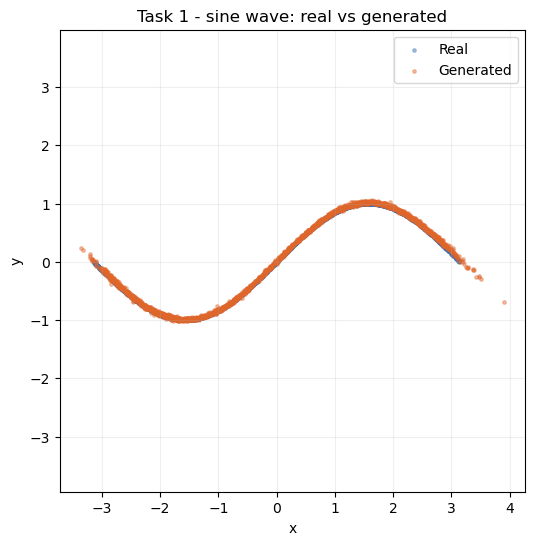

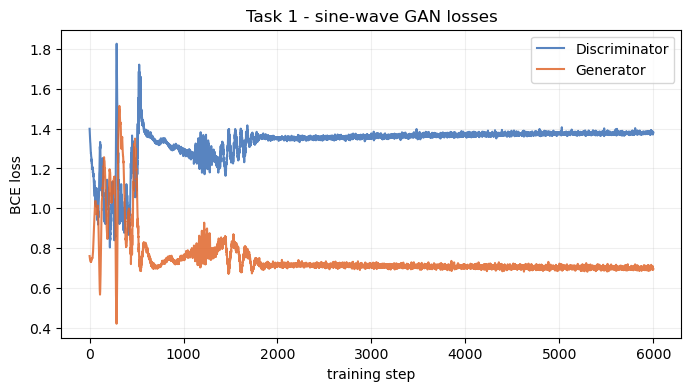

In [5]:
seed_everything()
sine_g = MlpGenerator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_GEN_ACT)
sine_d = MlpDiscriminator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_DISC_ACT)
sine_dh, sine_gh = train_2d_gan(sample_sine_wave, sine_g, sine_d, steps=6000)
scatter_2d(sample_sine_wave(2000).numpy(), draw_2d(sine_g, 2000),
           "Task 1 - sine wave: real vs generated", "part1_task1_sine.png")
plot_gan_losses(sine_dh, sine_gh, "Task 1 - sine-wave GAN losses", "part1_task1_sine_loss.png")

### c) Task 2: the noisy parametric curve y = sin(2x) + 0.3cos(5x) + e

For Task 2 the brief lets me pick a new 2D distribution, and I went with the noisy parametric curve y = sin(2x) + 0.3cos(5x) + e, where e is a small Gaussian noise term. It is a bit more interesting than the plain sine because of the higher-frequency second term and the noise band around the curve. This one gets a slightly longer run (8000 steps).

step     1/8000 | D=1.3977 | G=0.7608
step  2000/8000 | D=1.1652 | G=0.8429
step  4000/8000 | D=1.3147 | G=0.7963
step  6000/8000 | D=1.3523 | G=0.7334
step  8000/8000 | D=1.3705 | G=0.7229


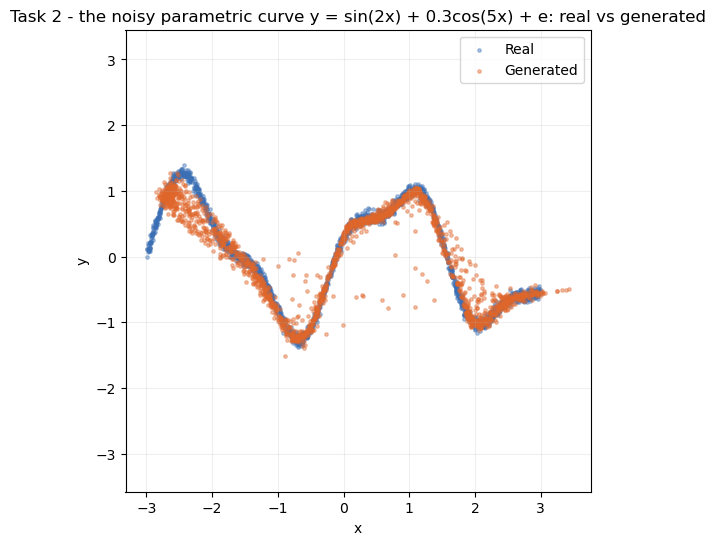

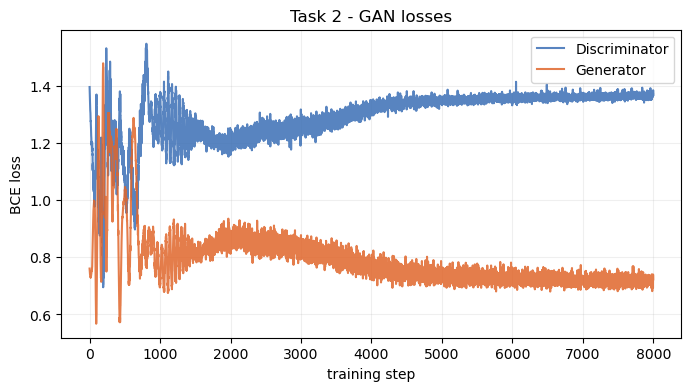

In [6]:
seed_everything()
task2_g = MlpGenerator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_GEN_ACT)
task2_d = MlpDiscriminator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_DISC_ACT)
task2_dh, task2_gh = train_2d_gan(sample_parametric_curve, task2_g, task2_d, steps=8000)
scatter_2d(sample_parametric_curve(2000).numpy(), draw_2d(task2_g, 2000),
           "Task 2 - the noisy parametric curve y = sin(2x) + 0.3cos(5x) + e: real vs generated", "part1_task2.png")
plot_gan_losses(task2_dh, task2_gh, "Task 2 - GAN losses", "part1_task2_loss.png")

### d) Task 3: modify the architecture and compare

Task 3 asks me to change the architecture and see what happens. I keep the same target (the noisy curve from Task 2) and the same training budget, and only change the generator: the baseline is 2 layers deep with ReLU, and the modified version is 4 layers deep with ELU. Both are plotted against the real data side by side so the difference is easy to see.

step     1/8000 | D=1.3977 | G=0.7608
step  2000/8000 | D=1.1652 | G=0.8429
step  4000/8000 | D=1.3147 | G=0.7963
step  6000/8000 | D=1.3523 | G=0.7334
step  8000/8000 | D=1.3705 | G=0.7229
step     1/8000 | D=1.3852 | G=0.6734
step  2000/8000 | D=1.3671 | G=0.8033
step  4000/8000 | D=1.3902 | G=0.7264
step  6000/8000 | D=1.3783 | G=0.7129
step  8000/8000 | D=1.3821 | G=0.7089


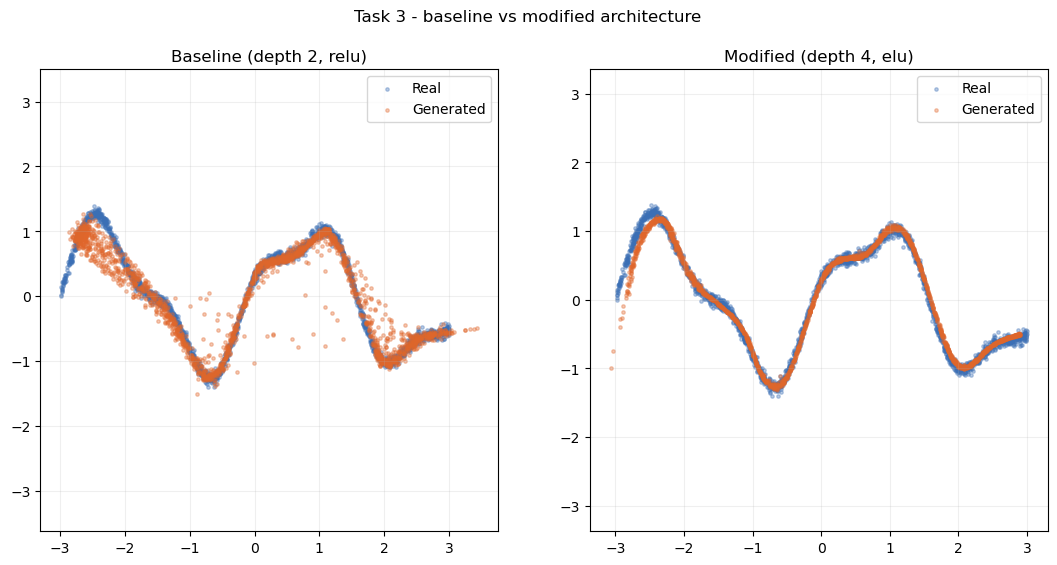

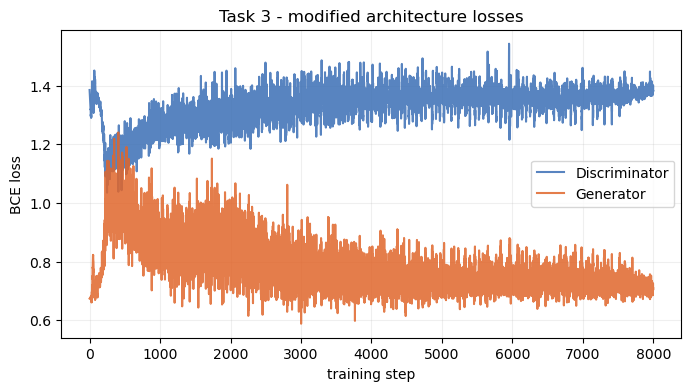

In [7]:
seed_everything()
base_g = MlpGenerator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_GEN_ACT)
base_d = MlpDiscriminator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_DISC_ACT)
base_dh, base_gh = train_2d_gan(sample_parametric_curve, base_g, base_d, steps=8000)

seed_everything()
mod_g = MlpGenerator(hidden=P1_HIDDEN, depth=P1_DEPTH + 2, activation=MOD_ACTIVATION)
mod_d = MlpDiscriminator(hidden=P1_HIDDEN, depth=P1_DEPTH + 2, activation=P1_DISC_ACT)
mod_dh, mod_gh = train_2d_gan(sample_parametric_curve, mod_g, mod_d, steps=8000)

reference = sample_parametric_curve(2000).numpy()
figure, axes = plt.subplots(1, 2, figsize=(13, 6))
for axis, pts, name in ((axes[0], draw_2d(base_g, 2000), f"Baseline (depth {P1_DEPTH}, {P1_GEN_ACT})"),
                        (axes[1], draw_2d(mod_g, 2000), f"Modified (depth {P1_DEPTH + 2}, {MOD_ACTIVATION})")):
    axis.scatter(reference[:, 0], reference[:, 1], s=6, alpha=0.35, label="Real", color="#3b6fb5")
    axis.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.35, label="Generated", color="#e0662b")
    axis.set_title(name); axis.legend(); axis.grid(alpha=0.2); axis.set_aspect("equal", adjustable="datalim")
figure.suptitle("Task 3 - baseline vs modified architecture")
figure.savefig(os.path.join(RESULTS_DIR, "part1_task3_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
plot_gan_losses(mod_dh, mod_gh, "Task 3 - modified architecture losses", "part1_task3_loss.png")

### e) Part 1 reflection

The sine-wave GAN in Task 1 came out about as well as I could have hoped. By the last few hundred steps the generated points lie almost exactly along y = sin(x), and the loss values back that up rather than contradicting it: the discriminator settles between roughly 1.35 and 1.39 and the generator between about 0.68 and 0.76. Those sit close to the equilibrium you would predict for this loss (around 2ln2 = 1.386 for D and ln2 = 0.693 for G), and neither loss runs away from the other, so I am fairly confident the two networks reached a balanced state instead of one overpowering the other.

Task 2 was a harder target because of the higher-frequency cos(5x) term and the added noise, but the generator handled it better than I expected. It traces the double-bump shape of y = sin(2x) + 0.3cos(5x), and rather than collapsing to a thin line through the middle it spreads its points into the same noisy band as the real data, which tells me it learned the variability and not just the average trend. The losses stay in a similar range to Task 1 (D roughly 1.17-1.40, G roughly 0.72-0.84), a little noisier, which seems reasonable for a more complicated curve.

For the architecture change in Task 3 I put the depth-2 ReLU baseline next to the deeper depth-4 ELU generator on the same target. The difference is visible but small: the deeper ELU version hugs the curve slightly more tightly and leaves fewer stray points drifting away from the shape. Neither version showed any instability, so the extra depth was not a problem to train. I would not read too much into the size of the gain, though, since a 2D curve is simple enough that even the baseline already does most of the job.

## TensorFlow/Keras setup

The next few parts switch over to TensorFlow/Keras, so this cell does the shared setup for them: seeding with `TF_SEED`, turning on GPU memory growth, and defining one loss-plotting helper I reuse. The image-specific helpers (FID and sample grids) are in their own cell further down, since only the image parts need them. Everything still saves into the same `RESULTS_DIR` I created back in Part 1.

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# os, numpy (np) and matplotlib (plt) already come in with the Part 1 (PyTorch) setup, which
# always runs first, so there is no need to import them again here.

TF_SEED = 2026


def tf_seed_everything(seed=TF_SEED):
    """Fix the Python hash seed and the NumPy and TensorFlow RNGs so the TF runs repeat."""
    import random as _random
    os.environ["PYTHONHASHSEED"] = str(seed)
    _random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


tf_seed_everything()

# Ask TensorFlow to grow GPU memory as it needs it rather than claiming all of it up front
# which matters here because PyTorch and TF are sharing the same GPU.
for _gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError as _err:
        print("memory-growth note:", _err)

# RESULTS_DIR normally comes from the Part 1 setup; recreate it if TF is ever run on its own.
try:
    RESULTS_DIR
except NameError:
    RESULTS_DIR = "results"
    os.makedirs(RESULTS_DIR, exist_ok=True)

print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1785405640.628315   12131 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.21.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
def tf_plot_losses(d_losses, g_losses, title, filename=None):
    plt.figure(figsize=(8, 4))
    plt.plot(d_losses, label="Discriminator", color="#3b6fb5", alpha=0.85)
    plt.plot(g_losses, label="Generator", color="#e0662b", alpha=0.85)
    plt.title(title); plt.xlabel("training step"); plt.ylabel("BCE loss"); plt.legend(); plt.grid(alpha=0.2)
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

### TensorFlow image helpers: InceptionV3 FID and grids

These helpers are shared by the TensorFlow image models. For FID I use Keras' InceptionV3 (pretrained on ImageNet) to pull out pooled features. Since my scans and sketches are grayscale, I repeat the single channel to three and resize up to 299x299 before feeding them in, because that is what InceptionV3 expects.

In [10]:
class TFInceptionFID:
    """Wraps an ImageNet InceptionV3 to pull pooled features and score FID on TF images."""

    def __init__(self):
        self.model = keras.applications.InceptionV3(
            include_top=False, pooling="avg", weights="imagenet")

    def features(self, images_pm1, batch=64):
        """Turn (N, H, W, 1 or 3) images in [-1, 1] into an (N, 2048) array of Inception features."""
        collected = []
        for start in range(0, len(images_pm1), batch):
            chunk = np.asarray(images_pm1[start:start + batch], dtype=np.float32)
            chunk = (chunk + 1.0) * 127.5                      # [-1,1] -> [0,255]
            if chunk.shape[-1] == 1:
                chunk = np.repeat(chunk, 3, axis=-1)
            resized = tf.image.resize(chunk, (299, 299))
            preprocessed = keras.applications.inception_v3.preprocess_input(resized)
            collected.append(self.model.predict(preprocessed, verbose=0))
        return np.concatenate(collected, axis=0)


def tf_frechet_distance(real_features, fake_features, eps=1e-6):
    """Compute the Frechet Inception Distance between two feature matrices; lower is better."""
    mu_real, mu_fake = real_features.mean(0), fake_features.mean(0)
    cov_real = np.cov(real_features, rowvar=False)
    cov_fake = np.cov(fake_features, rowvar=False)
    mean_gap = mu_real - mu_fake
    root = scipy.linalg.sqrtm(cov_real @ cov_fake)
    if isinstance(root, tuple):
        root = root[0]
    if not np.isfinite(root).all():
        pad = np.eye(cov_real.shape[0]) * eps
        root = scipy.linalg.sqrtm((cov_real + pad) @ (cov_fake + pad))
        if isinstance(root, tuple):
            root = root[0]
    if np.iscomplexobj(root):
        root = root.real
    return float(mean_gap @ mean_gap + np.trace(cov_real + cov_fake - 2.0 * root))


def tf_score_fid(fid_scorer, real_pm1, fake_pm1, tag, sample=2000):
    """Score FID between a real image array and a batch of generated images, both in [-1, 1]."""
    real_index = np.random.permutation(len(real_pm1))[:sample]
    real_features = fid_scorer.features(real_pm1[real_index])
    fake_features = fid_scorer.features(fake_pm1[:sample])
    value = tf_frechet_distance(real_features, fake_features)
    print(f"{tag}: FID = {value:.2f}")
    return value

In [11]:
def _tile_grayscale(images_pm1, cols=8, rows=8):
    """Lay (N, H, W, 1) images from [-1, 1] out into one [0, 1] grid ready for imshow."""
    images = ((np.asarray(images_pm1)[: cols * rows].clip(-1, 1) + 1.0) / 2.0)[..., 0]
    count, height, width = images.shape
    rows = int(np.ceil(count / cols))
    canvas = np.ones((rows * height, cols * width), dtype=np.float32)
    for index, image in enumerate(images):
        r, c = divmod(index, cols)
        canvas[r * height:(r + 1) * height, c * width:(c + 1) * width] = image
    return canvas


def tf_show_grid(images_pm1, title, filename=None, cols=8):
    plt.figure(figsize=(8, 8))
    plt.imshow(_tile_grayscale(images_pm1, cols=cols), cmap="gray")
    plt.title(title); plt.axis("off")
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def tf_show_real_vs_fake(real_pm1, fake_pm1, title, filename=None):
    figure, axes = plt.subplots(1, 2, figsize=(12, 6))
    for axis, batch, name in ((axes[0], real_pm1, "Real"), (axes[1], fake_pm1, "Generated")):
        axis.imshow(_tile_grayscale(batch, cols=8), cmap="gray")
        axis.set_title(name); axis.axis("off")
    figure.suptitle(title)
    if filename:
        figure.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def tf_show_epoch_snapshots(snapshots, title, filename=None):
    if not snapshots:
        return
    figure, axes = plt.subplots(1, len(snapshots), figsize=(3.2 * len(snapshots), 3.6))
    if len(snapshots) == 1:
        axes = [axes]
    for axis, (epoch_number, batch) in zip(axes, snapshots):
        axis.imshow(_tile_grayscale(batch, cols=4), cmap="gray")
        axis.set_title(f"epoch {epoch_number}"); axis.axis("off")
    figure.suptitle(title)
    if filename:
        figure.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

# Part 2.1 - OCT retinal images (TensorFlow/Keras DCGAN)

This part trains a DCGAN to generate synthetic OCT retinal scans from the OCTMNIST dataset. I built the generator and discriminator with the Keras Functional API (the generator upsamples with transposed convolutions) and trained them with a hand-written `tf.GradientTape` loop for 35 epochs, using a latent dimension of 100. After training I track the losses, put real and generated scans side by side, report an FID score, and then add a conditional GAN as the extension so I can ask for a specific class on demand.

In [12]:
TF_OCT_LATENT = 100
TF_OCT_EPOCHS = 35
print(f"TF OCT: latent={TF_OCT_LATENT} | epochs={TF_OCT_EPOCHS}")

TF OCT: latent=100 | epochs=35


## a) Load and explore OCTMNIST

First I load OCTMNIST through the `medmnist` package and get a feel for it: how many classes there are, how imbalanced they are, and what the scans actually look like. I also rescale the images to 32x32 in the [-1, 1] range so they line up with the generator's tanh output.

100%|██████████| 54.9M/54.9M [00:19<00:00, 2.80MB/s]


OCT classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}
OCT images : (97477, 28, 28)


I0000 00:00:1785405683.649559   12131 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20707 MB memory:  -> device: 0, name: NVIDIA A10G, pci bus id: 0000:00:1e.0, compute capability: 8.6


OCT tensor: (97477, 32, 32, 1) range -1.0 -> 1.0


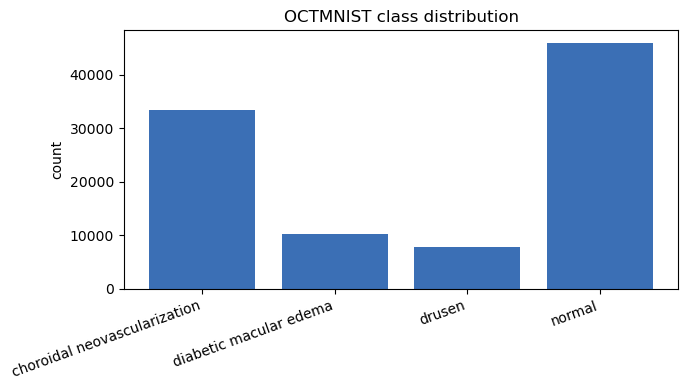

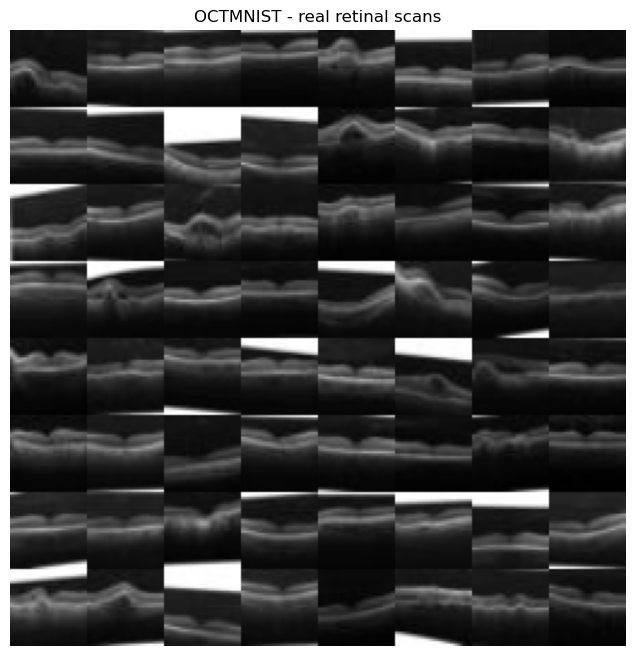

In [13]:
from medmnist import OCTMNIST, INFO

OCT_CLASS_NAMES = INFO["octmnist"]["label"]
OCT_NUM_CLASSES = len(OCT_CLASS_NAMES)
_oct_train = OCTMNIST(split="train", download=True)
oct_images_uint8 = _oct_train.imgs               # (N, 28, 28) uint8
oct_labels = _oct_train.labels.flatten().astype("int32")
print("OCT classes:", OCT_CLASS_NAMES)
print("OCT images :", oct_images_uint8.shape)


def oct_to_pm1(uint8_images, size=32):
    """Resize (N, 28, 28) uint8 scans to (N, size, size, 1) float32 in the [-1, 1] range."""
    scaled = uint8_images.astype("float32")[..., None] / 127.5 - 1.0
    return tf.image.resize(scaled, (size, size)).numpy()


oct_images = oct_to_pm1(oct_images_uint8)
print("OCT tensor:", oct_images.shape, "range", float(oct_images.min()), "->", float(oct_images.max()))

_values, _counts = np.unique(oct_labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([OCT_CLASS_NAMES[str(int(v))] for v in _values], _counts, color="#3b6fb5")
plt.title("OCTMNIST class distribution"); plt.ylabel("count"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "oct_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

tf_show_grid(oct_images[:64], "OCTMNIST - real retinal scans", "oct_real.png")

## b) DCGAN models (Sequential API)
Both networks are built with the Keras Sequential API as a plain list of layers. The generator projects the latent vector to a 4x4x256 map and grows it to 32x32 with three `Conv2DTranspose` blocks (BatchNorm + LeakyReLU), finishing on a tanh. The discriminator is a stack of strided `Conv2D` layers with dropout ending in a single logit.

In [ ]:
def build_oct_generator(latent_dim):
    """DCGAN generator (Sequential API, transposed convs): latent vector -> a 32x32x1 image."""
    return keras.Sequential([
        keras.Input(shape=(latent_dim,), name="noise"),
        layers.Dense(4 * 4 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((4, 4, 256)),
        layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(1, 4, strides=2, padding="same", use_bias=False, activation="tanh"),
    ], name="oct_generator")

def build_oct_discriminator():
    """DCGAN discriminator (Sequential API, strided convs + dropout): 32x32x1 image -> a logit."""
    return keras.Sequential([
        keras.Input(shape=(32, 32, 1), name="image"),
        layers.Conv2D(64, 4, strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Conv2D(128, 4, strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Conv2D(256, 4, strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1),
    ], name="oct_discriminator")

oct_generator = build_oct_generator(TF_OCT_LATENT)
oct_discriminator = build_oct_discriminator()
oct_generator.summary()
oct_discriminator.summary()


## c) Train with a manual `tf.GradientTape` loop

Rather than using `model.fit`, I train with an explicit `tf.GradientTape` loop so I can control the two update steps directly. I also apply a bit of one-sided label smoothing (real labels at 0.9) to stop the discriminator getting overconfident. The loop grabs a few sample grids at spaced-out epochs so I can watch the scans improve over time.

E0000 00:00:1785405690.942634   12131 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inoct_discriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1785405691.131489   13075 cuda_dnn.cc:461] Loaded cuDNN version 91002


[oct] epoch   1/35 | D=0.777 | G=1.959
[oct] epoch   2/35 | D=1.279 | G=0.749
[oct] epoch   3/35 | D=1.269 | G=1.045
[oct] epoch   4/35 | D=1.320 | G=0.913
[oct] epoch   5/35 | D=1.306 | G=0.840
[oct] epoch   6/35 | D=1.275 | G=0.843
[oct] epoch   7/35 | D=1.242 | G=0.962
[oct] epoch   8/35 | D=1.343 | G=0.823
[oct] epoch   9/35 | D=1.195 | G=1.160
[oct] epoch  10/35 | D=1.340 | G=0.837
[oct] epoch  11/35 | D=1.329 | G=0.760
[oct] epoch  12/35 | D=1.273 | G=0.960
[oct] epoch  13/35 | D=1.303 | G=0.967
[oct] epoch  14/35 | D=1.217 | G=1.029
[oct] epoch  15/35 | D=1.226 | G=1.058
[oct] epoch  16/35 | D=1.309 | G=0.878
[oct] epoch  17/35 | D=1.266 | G=1.057
[oct] epoch  18/35 | D=1.337 | G=0.801
[oct] epoch  19/35 | D=1.314 | G=0.910
[oct] epoch  20/35 | D=1.220 | G=1.130
[oct] epoch  21/35 | D=1.225 | G=1.023
[oct] epoch  22/35 | D=1.334 | G=0.974
[oct] epoch  23/35 | D=1.336 | G=0.886
[oct] epoch  24/35 | D=1.308 | G=0.871
[oct] epoch  25/35 | D=1.188 | G=1.145
[oct] epoch  26/35 | D=1.

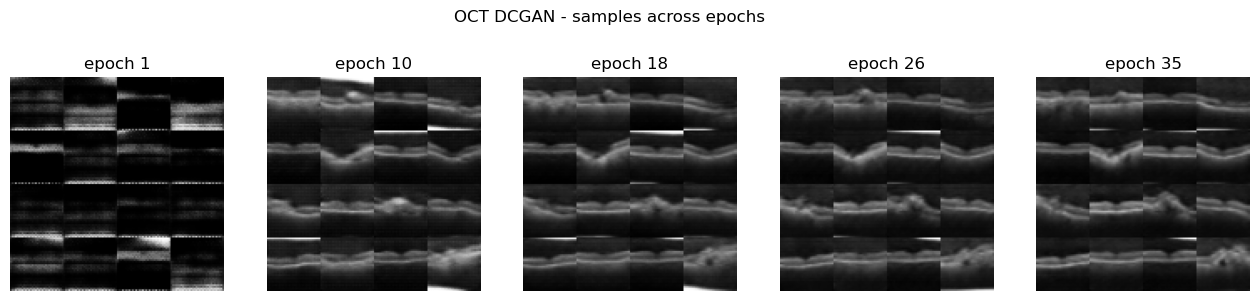

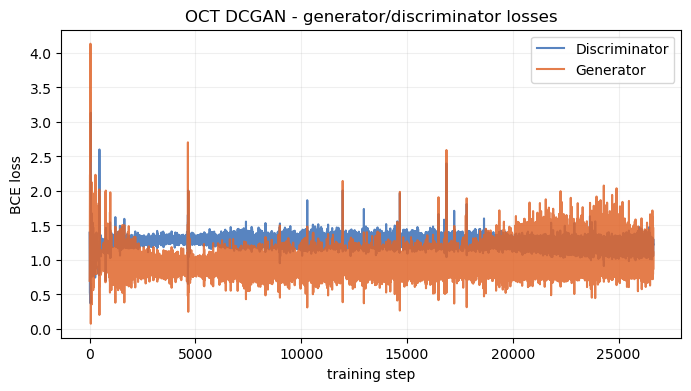

In [15]:
bce_logits = keras.losses.BinaryCrossentropy(from_logits=True)


def make_dataset(images_pm1, batch_size, labels=None):
    """Build a shuffled, batched tf.data pipeline over the in-memory image tensors."""
    if labels is None:
        dataset = tf.data.Dataset.from_tensor_slices(images_pm1)
    else:
        dataset = tf.data.Dataset.from_tensor_slices((images_pm1, labels))
    return dataset.shuffle(min(len(images_pm1), 10000)).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)


def train_oct_gan(generator, discriminator, images_pm1, epochs, latent_dim, batch_size=128):
    """Train the OCT DCGAN with a manual GradientTape loop and return (d_losses, g_losses).

    The @tf.function step closes over the generator, discriminator and optimizers rather
    than taking them as arguments, which is the usual way to stop it retracing every call.
    """
    tf_seed_everything()
    g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
    d_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)

    @tf.function
    def train_step(real_images):
        batch = tf.shape(real_images)[0]
        noise = tf.random.normal([batch, latent_dim])
        with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
            fake_images = generator(noise, training=True)
            real_logits = discriminator(real_images, training=True)
            fake_logits = discriminator(fake_images, training=True)
            d_loss = (bce_logits(tf.ones_like(real_logits) * 0.9, real_logits)
                      + bce_logits(tf.zeros_like(fake_logits), fake_logits))
            g_loss = bce_logits(tf.ones_like(fake_logits), fake_logits)
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))
        g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                  generator.trainable_variables))
        return d_loss, g_loss

    dataset = make_dataset(images_pm1, batch_size)
    snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, epochs, 5)))
    fixed_noise = tf.random.normal([16, latent_dim])
    d_losses, g_losses, snapshots = [], [], []
    for epoch in range(1, epochs + 1):
        for real_batch in dataset:
            d_loss, g_loss = train_step(real_batch)
            d_losses.append(float(d_loss)); g_losses.append(float(g_loss))
        print(f"[oct] epoch {epoch:>3}/{epochs} | D={float(d_loss):.3f} | G={float(g_loss):.3f}")
        if epoch in snapshot_epochs:
            snapshots.append((epoch, generator(fixed_noise, training=False).numpy()))
    tf_show_epoch_snapshots(snapshots, "OCT DCGAN - samples across epochs", "oct_evolution.png")
    return d_losses, g_losses


oct_d_losses, oct_g_losses = train_oct_gan(oct_generator, oct_discriminator, oct_images, TF_OCT_EPOCHS, TF_OCT_LATENT)
tf_plot_losses(oct_d_losses, oct_g_losses, "OCT DCGAN - generator/discriminator losses", "oct_losses.png")

## d) Evaluate: real vs generated and FID

Here I generate a fresh batch from the trained generator, show it next to real scans for a visual check, and then compute the FID against the real images so there is a number to go with the eyeballing.

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


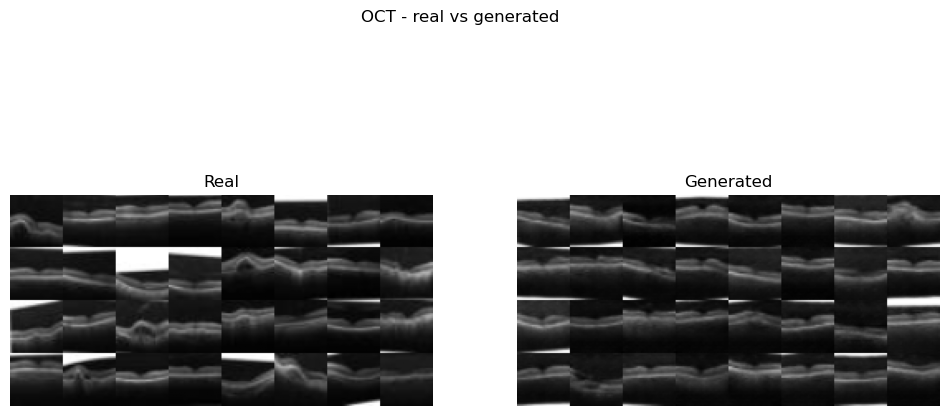

I0000 00:00:1785405959.624963   13072 service.cc:153] XLA service 0x5567a49e1300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785405959.624994   13072 service.cc:161]   StreamExecutor [0]: NVIDIA A10G, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1785405959.713021   13072 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785405975.124694   13072 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


OCT DCGAN: FID = 39.20


In [16]:
tf_fid = TFInceptionFID()

oct_fake = oct_generator(tf.random.normal([2000, TF_OCT_LATENT]), training=False).numpy()
tf_show_real_vs_fake(oct_images[:32], oct_fake[:32], "OCT - real vs generated", "oct_real_vs_fake.png")
oct_fid = tf_score_fid(tf_fid, oct_images, oct_fake, "OCT DCGAN")

## e) Extension - Conditional GAN (Functional API)

For the extra-credit extension I turned the DCGAN into a conditional one so I can choose which class to generate. The generator concatenates a learned class embedding onto the latent vector, and the discriminator gets the label fed in as an extra image channel. Both are multi-input Functional models and train with the same GradientTape recipe as before. At the end I generate one row per class to check the label is actually doing something.

In [17]:
def build_oct_cgan_generator(latent_dim, num_classes):
    noise = keras.Input(shape=(latent_dim,), name="noise")
    label = keras.Input(shape=(1,), dtype="int32", name="label")
    label_vec = layers.Flatten()(layers.Embedding(num_classes, 50)(label))
    x = layers.Concatenate()([noise, label_vec])
    x = layers.Dense(4 * 4 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((4, 4, 256))(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    image = layers.Conv2DTranspose(1, 4, strides=2, padding="same", use_bias=False, activation="tanh")(x)
    return keras.Model([noise, label], image, name="oct_cgan_generator")


def build_oct_cgan_discriminator(num_classes):
    image = keras.Input(shape=(32, 32, 1), name="image")
    label = keras.Input(shape=(1,), dtype="int32", name="label")
    label_map = layers.Reshape((32, 32, 1))(layers.Embedding(num_classes, 32 * 32)(label))
    x = layers.Concatenate()([image, label_map])
    x = layers.Conv2D(64, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(256, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)
    logit = layers.Dense(1)(x)
    return keras.Model([image, label], logit, name="oct_cgan_discriminator")

In [ ]:
def train_oct_cgan(images_pm1, labels, epochs, latent_dim, num_classes, batch_size=128):
    """Train the conditional OCT GAN; the GradientTape step closes over the models and optimizers."""
    tf_seed_everything()
    generator = build_oct_cgan_generator(latent_dim, num_classes)
    discriminator = build_oct_cgan_discriminator(num_classes)
    g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
    d_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)

    @tf.function
    def train_step(real_images, real_labels):
        batch = tf.shape(real_images)[0]
        noise = tf.random.normal([batch, latent_dim])
        sampled = tf.random.uniform([batch, 1], 0, num_classes, dtype=tf.int32)
        with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
            fake_images = generator([noise, sampled], training=True)
            real_logits = discriminator([real_images, real_labels], training=True)
            fake_logits = discriminator([fake_images, sampled], training=True)
            d_loss = (bce_logits(tf.ones_like(real_logits) * 0.9, real_logits)
                      + bce_logits(tf.zeros_like(fake_logits), fake_logits))
            g_loss = bce_logits(tf.ones_like(fake_logits), fake_logits)
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))
        g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                  generator.trainable_variables))
        return d_loss, g_loss

    dataset = make_dataset(images_pm1, batch_size, labels=labels.reshape(-1, 1))
    d_losses, g_losses = [], []
    for epoch in range(1, epochs + 1):
        for real_batch, label_batch in dataset:
            d_loss, g_loss = train_step(real_batch, label_batch)
            d_losses.append(float(d_loss)); g_losses.append(float(g_loss))
        print(f"[oct-cgan] epoch {epoch:>3}/{epochs} | D={float(d_loss):.3f} | G={float(g_loss):.3f}")
    return generator, d_losses, g_losses


oct_cgan_generator, oct_cgan_d, oct_cgan_g = train_oct_cgan(
    oct_images, oct_labels, TF_OCT_EPOCHS, TF_OCT_LATENT, OCT_NUM_CLASSES)
tf_plot_losses(oct_cgan_d, oct_cgan_g, "OCT conditional GAN - losses", "oct_cgan_losses.png")

# Generate one row of samples per class in a single batched call, then tile into rows.
_per_row = 8
_class_column = np.repeat(np.arange(OCT_NUM_CLASSES), _per_row).reshape(-1, 1)
_cgan_noise = tf.random.normal([len(_class_column), TF_OCT_LATENT])
_cgan_grid = oct_cgan_generator([_cgan_noise, _class_column], training=False).numpy()
tf_show_grid(_cgan_grid, "OCT conditional GAN - one class per row", "oct_cgan_per_class.png", cols=_per_row)
print("Rows top-to-bottom:", [OCT_CLASS_NAMES[str(_c)] for _c in range(OCT_NUM_CLASSES)])

## f) Reflection

Visually the synthetic scans get the overall anatomy right. Each one shows the bright, curved retinal band sitting on a darker background, and across a batch the band shifts position and curvature instead of repeating the same picture, so the generator is producing variety rather than one memorised image. What it does not capture is the fine texture: next to a real scan the fakes look smoothed over and lose the sharp sub-layer detail and speckle, which is the clearest giveaway that they are generated.

The conditional model behaves the way I hoped. Generating a row per class produces visibly different scans from one class to the next, so the label is steering the output rather than being ignored. The quality is not even across classes, though, and the ones with more training examples tend to look sharper, which is the usual consequence of training a conditional GAN on an imbalanced dataset like this one.

For a single number I used FID and got 39.20. I would treat that as a rough guide more than a precise score, mainly because it runs 28x28 medical grayscale (upscaled to 32x32) through an InceptionV3 trained on natural ImageNet photos, which is well outside what the metric was designed for. Even so, for a 35-epoch DCGAN it is a believable value and it agrees with what I see by eye.

A quick word on the setup behind this. The generator uses batch norm and ends in a tanh, which is why the images are loaded scaled to [-1, 1], the discriminator uses dropout of 0.3, and I apply one-sided label smoothing by setting the real labels to 0.9 so the discriminator does not become overconfident and cut off the generator's gradient. Both train with Adam at 2e-4 and beta_1 = 0.5 for 35 epochs from a latent dimension of 100. The epoch snapshots the loop saves show the band emerging out of noise gradually rather than appearing all at once, which lines up with the reasonably balanced loss curves.

One last thing the brief specifically asks about is the idea of a GAN "generating ducks" - the old duck test, where if something looks like a duck and quacks like a duck you assume it is one. A GAN runs on exactly that shortcut. The discriminator only ever learns to answer "does this look real", never "is this anatomically correct", so nothing in the training stops the generator from drawing a convincing structure that matches nothing in any real scan. On a retinal image that might mean inventing a bright region that reads like pathology when there is none, or quietly smoothing over a feature it was unsure about. That is the main reason I would only trust these synthetic scans for augmentation or teaching and never as evidence for a diagnosis, and why a classifier trained on a mix of real and generated scans is worth re-testing on real data alone, to check it has not just learned to spot GAN artefacts instead of real disease.

# Part 2.2 - Cybersecurity: synthetic traffic with CICIDS 2017 (TensorFlow/Keras)

This part moves away from images. CICIDS 2017 stores each network flow as around 78 numeric features, so instead of a convolutional GAN I use a dense (fully-connected) one, again in TensorFlow/Keras with a manual `tf.GradientTape` loop and a latent dimension of 48.

Following the brief, the plan is: combine the per-day CSVs and look at the class balance, then focus on the Wednesday file, train a feature-vector GAN on it, compare real and synthetic data with PCA and t-SNE plus some alignment-gap numbers, and finally (for the extension) retrain on all of the days.

The dataset is downloaded straight from Kaggle with `kagglehub`, so there are no CSV paths to set up by hand (a Kaggle login/token is needed the first time).

One thing worth flagging: the brief says "DDoS", but the attacks in the Wednesday file are actually single-source DoS (Hulk, GoldenEye, slowloris, Slowhttptest); the real DDoS traffic is in the Friday afternoon file. I have stuck with the named day and modelled Wednesday as BENIGN vs DoS, but wanted to note the mismatch.

In [19]:
CICIDS_LATENT = 48
print(f"CICIDS latent dim = {CICIDS_LATENT}")

CICIDS latent dim = 48


## a) Locate the CSV files

First I download the dataset from Kaggle with `kagglehub` and locate the eight day files inside whatever folder it lands in, failing early with a clear message if any are missing so I am not chasing a confusing error later on.

In [20]:
import os
import contextlib
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import kagglehub

# Pull the CICIDS 2017 dataset straight from Kaggle, so no local folder is needed.
# kagglehub logs the local cache path and a progress bar; silence them so no
# machine-specific paths are written into the notebook output.
with open(os.devnull, "w") as _devnull, \
        contextlib.redirect_stdout(_devnull), contextlib.redirect_stderr(_devnull):
    CICIDS_DIR = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

# The eight per-day capture files that make up CICIDS 2017.
CICIDS_CSV_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]


def find_csv(root, filename):
    """Search the downloaded dataset tree for a given CSV, since kagglehub can nest it."""
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    return None


cicids_csv_paths = []
missing_files = []
for name in CICIDS_CSV_FILES:
    found = find_csv(CICIDS_DIR, name)
    if found is None:
        missing_files.append(name)
    else:
        cicids_csv_paths.append(found)

if missing_files:
    raise FileNotFoundError(f"CICIDS CSV files not found in the downloaded dataset: {missing_files}")

print(f"Using {len(cicids_csv_paths)} CICIDS 2017 CSV files:")
for name in CICIDS_CSV_FILES:
    print("  ", name)


Using 8 CICIDS 2017 CSV files:
   Monday-WorkingHours.pcap_ISCX.csv
   Tuesday-WorkingHours.pcap_ISCX.csv
   Wednesday-workingHours.pcap_ISCX.csv
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   Friday-WorkingHours-Morning.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## b) Combine every day file and explore (EDA)

Here I read every day file, tag each row with its `SourceDay`, and stitch them into one frame. Then I explore it: the overall class balance, how many flows come from each day, how many numeric features there are, how many `Inf`/`NaN` values need cleaning, and what fraction of each day is attack traffic. CICIDS 2017 is very imbalanced (BENIGN swamps everything), so I plot the counts on a log scale, and I downcast the numeric columns to float32 to keep the memory down.

In [ ]:
DAY_KEYWORDS = {"monday": "Monday", "tuesday": "Tuesday", "wednesday": "Wednesday",
                "thursday": "Thursday", "friday": "Friday"}

def tag_day(path):
    """Infer the weekday for a CICIDS csv from its filename, or 'Unknown'."""
    stem = os.path.basename(path).lower()
    return next((label for key, label in DAY_KEYWORDS.items() if key in stem), "Unknown")

def read_day_csv(path):
    """Read one day's CSV, tidy columns, coerce numerics to float32 and tag the day.
    Returns None when the file has no Label column so it can be filtered out."""
    frame = pd.read_csv(path, low_memory=False)
    frame.columns = frame.columns.str.strip()
    frame = frame.loc[:, ~frame.columns.str.startswith("Unnamed")]
    if "Label" not in frame.columns:
        print(f"  skipping {os.path.basename(path)} (no Label column)")
        return None
    numeric_cols = frame.select_dtypes(include=[np.number]).columns
    frame[numeric_cols] = frame[numeric_cols].astype(np.float32)
    frame["Label"] = frame["Label"].astype(str).str.strip()
    frame["SourceDay"] = tag_day(path)
    return frame

loaded_days = [frame for frame in (read_day_csv(p) for p in cicids_csv_paths) if frame is not None]
if not loaded_days:
    raise ValueError("No CICIDS day files with a Label column were found.")
# join="inner" keeps only the columns every file shares, so a mismatched schema cannot
# introduce all-NaN phantom columns that would delete good rows during dropna().
combined_frame = pd.concat(loaded_days, ignore_index=True, join="inner")
del loaded_days
print(f"Combined dataset: {combined_frame.shape[0]:,} flows x {combined_frame.shape[1]} columns")


Overall class distribution (all days):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


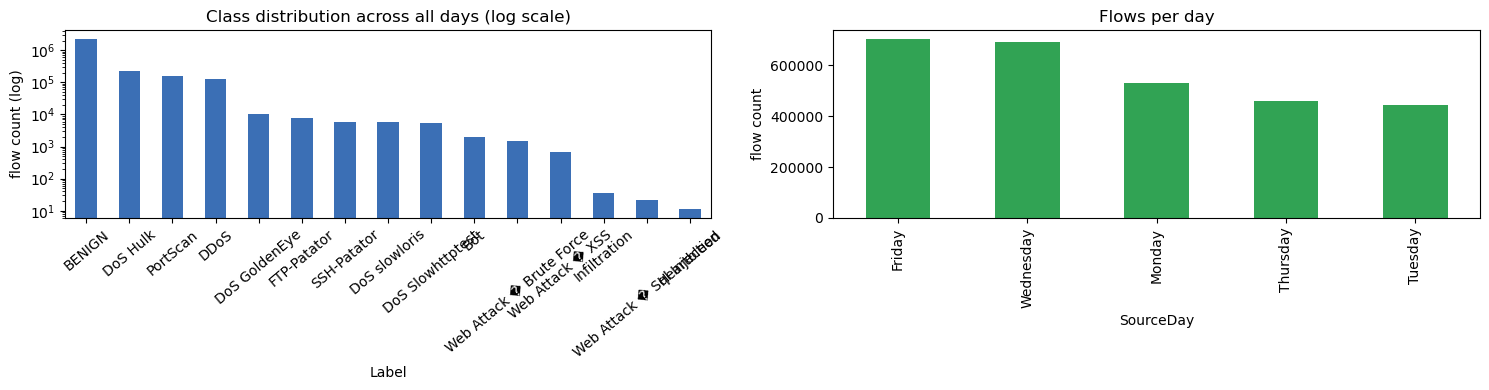

In [22]:
overall_distribution = combined_frame["Label"].value_counts()
print("Overall class distribution (all days):")
print(overall_distribution)

eda_figure, eda_axes = plt.subplots(1, 2, figsize=(15, 4))
overall_distribution.plot(kind="bar", ax=eda_axes[0], color="#3b6fb5", logy=True)
eda_axes[0].set_title("Class distribution across all days (log scale)")
eda_axes[0].set_ylabel("flow count (log)")
eda_axes[0].tick_params(axis="x", rotation=40)
combined_frame["SourceDay"].value_counts().plot(kind="bar", ax=eda_axes[1], color="#31a354")
eda_axes[1].set_title("Flows per day"); eda_axes[1].set_ylabel("flow count")
eda_figure.tight_layout()
eda_figure.savefig(os.path.join(RESULTS_DIR, "cicids_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [23]:
cicids_feature_columns = combined_frame.drop(columns=["Label", "SourceDay"]).select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric feature count: {len(cicids_feature_columns)}")
print("First 12 features:", cicids_feature_columns[:12])

numeric_block = combined_frame[cicids_feature_columns].to_numpy()
print(f"Infinite values across features: {int(np.isinf(numeric_block).sum()):,}")
print(f"Missing (NaN) values across features: {int(np.isnan(numeric_block).sum()):,}")
del numeric_block

attack_fraction_by_day = (
    combined_frame.assign(_is_attack=(combined_frame["Label"] != "BENIGN").astype(int))
    .groupby("SourceDay")["_is_attack"].mean().sort_values()
)
print("Fraction of attack flows per day:")
print(attack_fraction_by_day)

Numeric feature count: 78
First 12 features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min']
Infinite values across features: 4,376
Missing (NaN) values across features: 1,358
Fraction of attack flows per day:
SourceDay
Monday       0.000000
Thursday     0.004828
Tuesday      0.031027
Wednesday    0.364762
Friday       0.410843
Name: _is_attack, dtype: float64


## c) Focus on Wednesday (BENIGN vs DoS) and preprocess
As the brief asks, the GAN is trained on the Wednesday file only (`SourceDay == "Wednesday"`). The preprocessing is wrapped in `build_wednesday_matrix`: drop any rows with `Inf`/`NaN`, build the binary BENIGN-vs-DoS label, and keep the numeric features. Rather than a plain z-score I use a Yeo-Johnson `PowerTransformer`, which handles the heavy right-skew in the CICIDS flow statistics much better, and then clip to +/-5 so a few extreme outliers cannot destabilise GAN training.

In [ ]:
def numeric_feature_frame(frame):
    """Drop the Label/SourceDay columns and return the numeric features as float32."""
    return (frame.drop(columns=["Label", "SourceDay"], errors="ignore")
                 .select_dtypes(include=[np.number]).astype(np.float32))

def build_wednesday_matrix(frame):
    """Take the Wednesday split, drop Inf/NaN rows, and return the numeric feature frame,
    the binary BENIGN-vs-DoS indicator, and the feature-column names."""
    wed = frame[frame["SourceDay"] == "Wednesday"].copy()
    if wed.empty:
        raise ValueError("No Wednesday rows in the combined dataset - check the file names.")
    print("Wednesday class balance:")
    print(wed["Label"].value_counts())
    wed = wed.replace([np.inf, -np.inf], np.nan).dropna()
    labels = wed["Label"].ne("BENIGN").astype(int).to_numpy()
    numeric = numeric_feature_frame(wed)
    return numeric, labels, list(numeric.columns)

feature_frame, attack_indicator, feature_names = build_wednesday_matrix(combined_frame)
feature_matrix = feature_frame.to_numpy()
print(f"Feature vectors: {feature_matrix.shape[0]} rows x {feature_matrix.shape[1]} features")

from sklearn.preprocessing import PowerTransformer
# Yeo-Johnson tames the heavy right-skew in the CICIDS flow features far better than a
# plain z-score would; standardize=True still leaves the output roughly unit-variance.
feature_scaler = PowerTransformer(method="yeo-johnson", standardize=True).fit(feature_matrix)
def scale_features(matrix):
    """Power-transform the features and clip to +/-5 to contain any residual outliers."""
    return np.clip(feature_scaler.transform(matrix), -5.0, 5.0).astype(np.float32)
scaled_features = scale_features(feature_matrix)


In [25]:
tf_seed_everything()
cicids_row_cap = 20000
cicids_row_indices = np.random.permutation(scaled_features.shape[0])[:cicids_row_cap]
cicids_training_features = scaled_features[cicids_row_indices]
cicids_feature_dim = cicids_training_features.shape[1]
print(f"Training the tabular GAN on {cicids_training_features.shape[0]} rows x {cicids_feature_dim} features")

Training the tabular GAN on 20000 rows x 78 features


## d) Feature-vector GAN (dense layers) trained with `tf.GradientTape`

The generator maps the latent noise up to a full feature vector, with a plain linear output since the standardised features are not bounded to any range. The discriminator is a dense network ending in a single logit. As with the OCT model, training is a manual `tf.GradientTape` loop with one-sided label smoothing.

In [ ]:
def build_traffic_generator(latent_dim, feature_dim):
    """Dense generator that widens 96 -> 192 -> 384 with BatchNorm + ReLU, then a linear
    projection to the feature vector (standardised features are not range-bounded)."""
    noise = keras.Input(shape=(latent_dim,))
    x = noise
    for units in (96, 192, 384):
        x = layers.Dense(units)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    features = layers.Dense(feature_dim)(x)
    return keras.Model(noise, features, name="traffic_generator")

def build_traffic_discriminator(feature_dim):
    """Dense critic that narrows 384 -> 192 -> 96 with LeakyReLU + dropout, ending in a
    single logit."""
    vector = keras.Input(shape=(feature_dim,))
    x = vector
    for units in (384, 192, 96):
        x = layers.Dense(units)(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)
    logit = layers.Dense(1)(x)
    return keras.Model(vector, logit, name="traffic_discriminator")


In [27]:
traffic_bce = keras.losses.BinaryCrossentropy(from_logits=True)


def make_traffic_dataset(features, batch_size):
    return (tf.data.Dataset.from_tensor_slices(features.astype("float32"))
            .shuffle(min(len(features), 10000)).batch(batch_size, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))


def train_traffic_gan(features, epochs, latent_dim, batch_size=256):
    """Train the tabular GAN with a manual GradientTape loop and return (gen, d_hist, g_hist)."""
    tf_seed_everything()
    generator = build_traffic_generator(latent_dim, features.shape[1])
    discriminator = build_traffic_discriminator(features.shape[1])
    g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
    d_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)

    @tf.function
    def train_step(real_vectors):
        batch = tf.shape(real_vectors)[0]
        noise = tf.random.normal([batch, latent_dim])
        with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
            fake_vectors = generator(noise, training=True)
            real_logits = discriminator(real_vectors, training=True)
            fake_logits = discriminator(fake_vectors, training=True)
            d_loss = (traffic_bce(tf.ones_like(real_logits) * 0.9, real_logits)
                      + traffic_bce(tf.zeros_like(fake_logits), fake_logits))
            g_loss = traffic_bce(tf.ones_like(fake_logits), fake_logits)
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))
        g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                  generator.trainable_variables))
        return d_loss, g_loss

    dataset = make_traffic_dataset(features, batch_size)
    d_hist, g_hist = [], []
    for epoch in range(1, epochs + 1):
        for real_batch in dataset:
            d_loss, g_loss = train_step(real_batch)
            d_hist.append(float(d_loss)); g_hist.append(float(g_loss))
        if epoch == 1 or epoch % 10 == 0:
            print(f"epoch {epoch:>3}/{epochs} | D={float(d_loss):.4f} | G={float(g_loss):.4f}")
    return generator, d_hist, g_hist

epoch   1/60 | D=1.1265 | G=1.1069
epoch  10/60 | D=0.9686 | G=1.3517
epoch  20/60 | D=0.9268 | G=1.4923
epoch  30/60 | D=0.9352 | G=1.5522
epoch  40/60 | D=0.9466 | G=1.6738
epoch  50/60 | D=0.9460 | G=1.6778
epoch  60/60 | D=0.8653 | G=1.7276


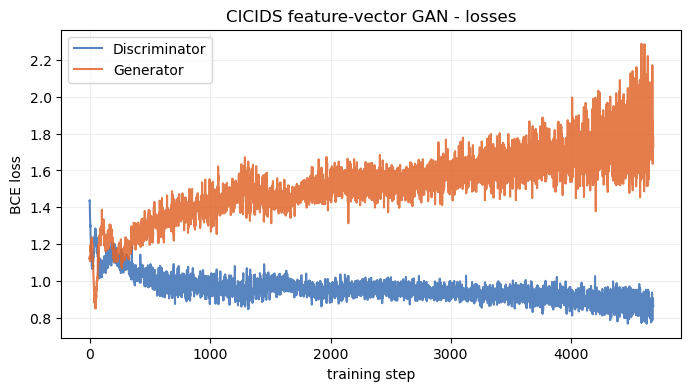

In [28]:
cicids_epochs = 60
cicids_generator, cicids_d_losses, cicids_g_losses = train_traffic_gan(
    cicids_training_features, cicids_epochs, CICIDS_LATENT)
tf_plot_losses(cicids_d_losses, cicids_g_losses, "CICIDS feature-vector GAN - losses", "cicids_loss_curves.png")

## e) Compare real vs synthetic distributions (PCA, t-SNE, alignment gaps)

To judge how good the synthetic traffic is I project both the real and generated vectors down to 2D. PCA gives a quick linear view where I colour real BENIGN, real DoS and synthetic separately, and t-SNE gives a non-linear view that is better at showing local structure. On top of the plots I compute alignment-gap numbers - the mean absolute difference in per-feature means and standard deviations - so I have a quantitative handle on how closely the synthetic marginals match the real ones.

In [ ]:
def generate_traffic(generator, count):
    return generator(tf.random.normal([count, CICIDS_LATENT]), training=False).numpy()

cicids_eval_count = 2000
real_idx = np.random.permutation(scaled_features.shape[0])[:cicids_eval_count]
cicids_real = scaled_features[real_idx]
cicids_real_labels = attack_indicator[real_idx]
cicids_synthetic = generate_traffic(cicids_generator, cicids_eval_count)

def scatter_projection(groups, title, axis_labels, filename):
    """Plot several labelled 2D point groups on one figure, then save it. Each group is
    a (points, label, colour) triple, so PCA and t-SNE reuse the same drawing code."""
    plt.figure(figsize=(7, 6))
    for points, name, colour in groups:
        plt.scatter(points[:, 0], points[:, 1], s=8, alpha=0.4, label=name, color=colour)
    plt.title(title)
    plt.xlabel(axis_labels[0]); plt.ylabel(axis_labels[1])
    plt.legend(); plt.grid(alpha=0.2)
    plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

cicids_pca = PCA(n_components=2).fit(cicids_real)
real_pca = cicids_pca.transform(cicids_real)
synthetic_pca = cicids_pca.transform(cicids_synthetic)
scatter_projection(
    [(real_pca[cicids_real_labels == 0], "Real BENIGN", "#3b6fb5"),
     (real_pca[cicids_real_labels == 1], "Real DoS", "#31a354"),
     (synthetic_pca, "Synthetic", "#e0662b")],
    "CICIDS - PCA of real vs synthetic feature vectors", ("PC 1", "PC 2"), "cicids_pca.png")


In [ ]:
cicids_tsne_input = np.vstack([cicids_real, cicids_synthetic])
cicids_tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=TF_SEED).fit_transform(cicids_tsne_input)
real_tsne = cicids_tsne[:cicids_eval_count]
synthetic_tsne = cicids_tsne[cicids_eval_count:]
scatter_projection(
    [(real_tsne, "Real", "#3b6fb5"), (synthetic_tsne, "Synthetic", "#e0662b")],
    "CICIDS - t-SNE of real vs synthetic feature vectors", ("t-SNE 1", "t-SNE 2"), "cicids_tsne.png")


In [ ]:
def alignment_gaps(real_features, fake_features):
    """Per-feature absolute gaps in mean and standard deviation (real vs synthetic)."""
    mu_gap = np.abs(real_features.mean(axis=0) - fake_features.mean(axis=0))
    sd_gap = np.abs(real_features.std(axis=0) - fake_features.std(axis=0))
    return mu_gap, sd_gap

cicids_mean_gap, cicids_std_gap = alignment_gaps(cicids_real, cicids_synthetic)
print(f"CICIDS alignment gap | mean |dmu| = {cicids_mean_gap.mean():.4f} | mean |dsigma| = {cicids_std_gap.mean():.4f}")
worst = np.argsort(cicids_mean_gap)[::-1][:15]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(np.arange(len(worst)), cicids_mean_gap[worst], color="#3b6fb5")
ax.set_xticks(np.arange(len(worst)))
ax.set_xticklabels([feature_names[i] for i in worst], rotation=75, ha="right")
ax.set(title="CICIDS - top-15 per-feature mean alignment gaps (lower is better)",
       ylabel="|mean_real - mean_synth|")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "cicids_alignment_gaps.png"), dpi=150, bbox_inches="tight")
plt.show()


## f) Extension - Full multi-day dataset and generalisation

For the extension I train the same dense GAN on the whole CICIDS 2017 dataset (all days, every attack type) to see whether a single unconditional generator can cover all the different attack families or just collapses onto the dominant BENIGN traffic. In the PCA plot I colour the real points by attack family so it is easier to see where the synthetic points land relative to each type.

In [ ]:
FAMILY_RULES = [
    ("BENIGN", lambda s: s == "BENIGN"),
    ("DoS", lambda s: s.startswith("DoS")),
    ("DDoS", lambda s: s == "DDoS"),
    ("PortScan", lambda s: s == "PortScan"),
    ("Web Attack", lambda s: s.startswith("Web Attack")),
    ("Bot", lambda s: s == "Bot"),
    ("Brute Force", lambda s: s.startswith(("FTP", "SSH"))),
    ("Infiltration", lambda s: s == "Infiltration"),
    ("Heartbleed", lambda s: s == "Heartbleed"),
]

def coarse_attack_family(label):
    """Collapse the detailed CICIDS labels into a few broad attack families for plotting."""
    for family, matches in FAMILY_RULES:
        if matches(label):
            return family
    return "Other"

tf_seed_everything()
clean_all = combined_frame.replace([np.inf, -np.inf], np.nan).dropna()
full_families = clean_all["Label"].map(coarse_attack_family).to_numpy()
full_matrix = numeric_feature_frame(clean_all).to_numpy()
# Reuse the Wednesday-fitted scaler so both runs live on the same feature scale.
full_scaled = scale_features(full_matrix)
del clean_all
full_row_cap = 30000
full_subset = np.random.permutation(full_scaled.shape[0])[:full_row_cap]
full_training_features = full_scaled[full_subset]
print(f"Training the full-dataset GAN on {full_training_features.shape[0]} rows sampled from all days")


In [ ]:
full_generator, full_d_losses, full_g_losses = train_traffic_gan(
    full_training_features, cicids_epochs, CICIDS_LATENT)
tf_plot_losses(full_d_losses, full_g_losses, "CICIDS full-dataset GAN - losses", "cicids_full_loss_curves.png")
full_eval_count = 2500
full_real_idx = np.random.permutation(full_scaled.shape[0])[:full_eval_count]
full_real = full_scaled[full_real_idx]
full_real_families = full_families[full_real_idx]
full_synthetic = generate_traffic(full_generator, full_eval_count)
full_pca = PCA(n_components=2).fit(full_real)
full_real_pca = full_pca.transform(full_real)
full_synthetic_pca = full_pca.transform(full_synthetic)
family_groups = [(full_real_pca[full_real_families == fam], f"Real {fam}", None)
                 for fam in sorted(set(full_real_families))]
family_groups.append((full_synthetic_pca, "Synthetic", "black"))
scatter_projection(family_groups, "CICIDS full dataset - PCA (real by attack family vs synthetic)",
                   ("PC 1", "PC 2"), "cicids_full_pca.png")
full_mean_gap, full_std_gap = alignment_gaps(full_real, full_synthetic)
print(f"Full-dataset alignment gap | mean |dmu| = {full_mean_gap.mean():.4f} "
      f"(Wednesday-only {cicids_mean_gap.mean():.4f})")
print(f"Full-dataset alignment gap | mean |dsigma| = {full_std_gap.mean():.4f} "
      f"(Wednesday-only {cicids_std_gap.mean():.4f})")


## g) Reflection

The two projections tell a consistent story. In both the PCA and the t-SNE plots the synthetic points fall inside the main mass of real traffic instead of forming their own separate blob, so at a coarse level the generator has found the right region of feature space. The catch is that its cloud is noticeably tighter than the real one and does not reach into the tails. The alignment-gap numbers put that more precisely: on the Wednesday data the mean absolute error in per-feature means is 0.1227 while the error in per-feature standard deviations is 0.2780, so the model gets the average of each feature about right but understates how far the values actually spread.

The full-dataset run gave a result I did not expect. Trained across all eight days, the gaps come out slightly smaller (0.1059 for the means, 0.2669 for the stds) than on Wednesday alone. I would normally expect one unconditional generator to do worse when it has to cover many attack types at once, since it has more modes to fit with the same capacity, so I think the extra volume of data is roughly cancelling out the extra diversity here. Even then, I doubt the model represents the rare classes well; Heartbleed, Infiltration and SQL Injection have only a handful of rows even after combining every day, so the generator almost certainly leans towards BENIGN and the high-volume attacks.

There is also a labelling point I should flag, which the brief itself hints at. The Wednesday file's attacks are single-source DoS (Hulk, GoldenEye, slowloris, Slowhttptest), not DDoS; the actual DDoS flows live in the Friday file. The Wednesday run is therefore BENIGN versus DoS as instructed, and the only place real DDoS traffic enters is the all-days extension.

On the modelling side the network is deliberately simple: a dense generator that widens 128 to 256 with batch norm and ReLU and ends in a linear layer (no tanh, because the standardised features are unbounded), paired with a dense discriminator that narrows 256 to 128 with LeakyReLU and dropout. Both use Adam at 2e-4 with beta_1 = 0.5 and one-sided label smoothing over 60 epochs from a latent dimension of 48. The preprocessing turned out to matter as much as the architecture: standardising and then clipping to +/-5 sigma is what keeps CICIDS's extreme outliers from destabilising training. I trained on 20,000 sampled Wednesday rows and 30,000 for the full run, and reused the Wednesday scaler in the extension on purpose, so the two sets of alignment-gap figures are measured on the same scale and can be compared directly.

The brief also asks for a note on GANs "generating ducks", and the duck test carries over to tabular traffic almost too neatly. A generated flow only has to look statistically like real traffic to fool the discriminator, which is a far weaker bar than actually behaving like a real attack. That matters if this synthetic data were ever used to pad out an intrusion-detection training set: a fake "attack" that matches no real signature could teach a classifier the wrong pattern and let real attacks slip through, while a fake "benign" row drifting toward attack-like values could nudge the decision boundary and raise false alarms on ordinary traffic. The awkward part is that a row of 78 numbers gives you nothing to eyeball the way an image does, so the per-feature alignment gaps from the previous section - especially the standard-deviation gap, where this kind of quiet drift shows up first - are really the only sanity check available.

### PyTorch image helpers: InceptionV3 FID and image grids

These are the equivalent helpers for the PyTorch image model in Part 2.3. FID uses torchvision's ImageNet-pretrained InceptionV3 and its 2048-d pooled features. As with the TensorFlow version, grayscale sketches get repeated to three channels and resized to 299x299 first.

In [34]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid
from torchvision.models import inception_v3, Inception_V3_Weights


def to_pm1_tensor(uint8_images, size=32):
    """Convert (N, H, W) uint8 images into an (N, 1, size, size) float tensor in [-1, 1]."""
    tensor = torch.from_numpy(uint8_images).float().unsqueeze(1) / 127.5 - 1.0
    if tensor.shape[-1] != size:
        tensor = F.interpolate(tensor, size=(size, size), mode="bilinear", align_corners=False)
    return tensor


def pm1_to_unit(tensor):
    """Rescale a tensor from [-1, 1] to [0, 1] for the Inception network or for display."""
    return (tensor.clamp(-1, 1) + 1.0) / 2.0


class InceptionFID:
    """torchvision InceptionV3 used as a pooled-feature extractor for computing FID."""

    _MEAN = (0.485, 0.456, 0.406)
    _STD = (0.229, 0.224, 0.225)

    def __init__(self, device):
        network = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        network.fc = nn.Identity()
        self.network = network.eval().to(device)
        self.device = device
        self.mean = torch.tensor(self._MEAN, device=device).view(1, 3, 1, 1)
        self.std = torch.tensor(self._STD, device=device).view(1, 3, 1, 1)

    @torch.no_grad()
    def features(self, images_unit, batch=64):
        """Return the (N, 2048) feature array for a batch of [0, 1]-scaled images."""
        if images_unit.shape[1] == 1:
            images_unit = images_unit.repeat(1, 3, 1, 1)
        collected = []
        for start in range(0, images_unit.shape[0], batch):
            chunk = images_unit[start:start + batch].to(self.device)
            chunk = F.interpolate(chunk, size=(299, 299), mode="bilinear", align_corners=False)
            chunk = (chunk - self.mean) / self.std
            collected.append(self.network(chunk).cpu().numpy())
        return np.concatenate(collected, axis=0)


def frechet_distance(real_features, fake_features, eps=1e-6):
    """Compute the Frechet Inception Distance between two feature matrices; lower is better."""
    mu_real, mu_fake = real_features.mean(0), fake_features.mean(0)
    cov_real = np.cov(real_features, rowvar=False)
    cov_fake = np.cov(fake_features, rowvar=False)
    mean_gap = mu_real - mu_fake
    covariance_root = scipy.linalg.sqrtm(cov_real @ cov_fake)
    if isinstance(covariance_root, tuple):
        covariance_root = covariance_root[0]
    if not np.isfinite(covariance_root).all():
        pad = np.eye(cov_real.shape[0]) * eps
        covariance_root = scipy.linalg.sqrtm((cov_real + pad) @ (cov_fake + pad))
        if isinstance(covariance_root, tuple):
            covariance_root = covariance_root[0]
    if np.iscomplexobj(covariance_root):
        covariance_root = covariance_root.real
    return float(mean_gap @ mean_gap + np.trace(cov_real + cov_fake - 2.0 * covariance_root))


def score_fid(real_uint8, fake_pm1, tag, sample=2000):
    """Score FID between a real uint8 image array and a batch of generated [-1, 1] images."""
    real_index = np.random.permutation(len(real_uint8))[:sample]
    real_features = torch_fid.features(pm1_to_unit(to_pm1_tensor(real_uint8[real_index])))
    fake_features = torch_fid.features(pm1_to_unit(fake_pm1))
    value = frechet_distance(real_features, fake_features)
    print(f"{tag}: FID = {value:.2f}")
    return value


@torch.no_grad()
def show_image_grid(images_pm1, title, filename=None, cols=8):
    """Draw a grid from images that are given in the [-1, 1] range."""
    grid = make_grid(pm1_to_unit(images_pm1.detach().cpu()), nrow=cols, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
    plt.title(title); plt.axis("off")
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def show_real_vs_fake(real_pm1, fake_pm1, title, filename=None, count=32):
    """Show the real and generated image grids side by side."""
    figure, axes = plt.subplots(1, 2, figsize=(12, 6))
    for axis, batch, name in ((axes[0], real_pm1, "Real"), (axes[1], fake_pm1, "Generated")):
        grid = make_grid(pm1_to_unit(batch[:count].detach().cpu()), nrow=8, padding=2)
        axis.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
        axis.set_title(name); axis.axis("off")
    figure.suptitle(title)
    if filename:
        figure.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def show_epoch_snapshots(snapshots, title, filename=None):
    """Show the generated grids that were saved at different epochs during training."""
    if not snapshots:
        return
    figure, axes = plt.subplots(1, len(snapshots), figsize=(3.2 * len(snapshots), 3.6))
    if len(snapshots) == 1:
        axes = [axes]
    for axis, (epoch_number, batch) in zip(axes, snapshots):
        grid = make_grid(pm1_to_unit(batch.detach().cpu()), nrow=4, padding=2)
        axis.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
        axis.set_title(f"epoch {epoch_number}"); axis.axis("off")
    figure.suptitle(title)
    if filename:
        figure.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
import contextlib, os

# Build one Inception feature extractor and reuse it for every PyTorch FID score.
# Silence torchvision's weight-download log so no local cache path leaks into the output.
with open(os.devnull, "w") as _devnull, \
        contextlib.redirect_stdout(_devnull), contextlib.redirect_stderr(_devnull):
    torch_fid = InceptionFID(DEVICE)

# Part 2.3 - Creative AI: QuickDraw sketches (PyTorch DCGAN)

The last part is a DCGAN, back in PyTorch this time, that learns to draw the QuickDraw *birthday cake* category (latent dimension 128). The bitmaps are loaded straight into memory as a `TensorDataset`. I track the generator and discriminator losses, snapshot the samples at a few epochs so I can see them develop, and score the final generator with FID. The extension runs the same pipeline on a couple more categories and checks whether FID lines up with a simple ink-density measure of how busy the sketches are.

In [36]:
QUICKDRAW_LATENT = 128
USE_CUSTOM_LOADER = False
QUICKDRAW_EXTRA_CATEGORIES = ['cat', 'house']
print(f"QuickDraw latent={QUICKDRAW_LATENT} | custom_loader={USE_CUSTOM_LOADER} | "
      f"extras={QUICKDRAW_EXTRA_CATEGORIES}")

QuickDraw latent=128 | custom_loader=False | extras=['cat', 'house']


## a) Download and explore the 'birthday cake' category

I download the birthday-cake bitmaps directly from the QuickDraw dataset and plot a grid of them first, just to see what the real sketches look like before trying to model them.

In [ ]:
import urllib.request, shutil
QUICKDRAW_DIR = os.path.join(RESULTS_DIR, "quickdraw")
os.makedirs(QUICKDRAW_DIR, exist_ok=True)

def download_quickdraw(category):
    """Fetch one QuickDraw numpy-bitmap category (cached locally); (N, 28, 28) uint8 array."""
    local = os.path.join(QUICKDRAW_DIR, category.replace(" ", "_") + ".npy")
    if not os.path.exists(local):
        print("downloading QuickDraw category:", category)
        remote = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/%s.npy" % category.replace(" ", "%20")
        request = urllib.request.Request(remote, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request) as response, open(local, "wb") as handle:
            shutil.copyfileobj(response, handle)
    return np.load(local).reshape(-1, 28, 28)

cake_images = download_quickdraw("birthday cake")
print("birthday cake bitmaps:", cake_images.shape)
show_image_grid(to_pm1_tensor(cake_images[:64]), "QuickDraw 'birthday cake' - real sketches", "qd_cake_real.png")


## b) DCGAN model, data pipeline and training loop

The generator takes a latent vector and grows it into a 32x32 image through a stack of transposed convolutions, and the discriminator mirrors that with strided convolutions down to a single logit. Both are `nn.Module` subclasses and follow the DCGAN conventions (batch norm, ReLU in the generator, LeakyReLU in the discriminator, and the N(0, 0.02) weight init from the original paper). Training uses the non-saturating BCE loss with one-sided label smoothing.

In [38]:
class QuickDrawGenerator(nn.Module):
    """DCGAN generator that upsamples a latent vector to a (1, 32, 32) image in [-1, 1]."""

    def __init__(self, latent_dim, feature_maps=64, channels=1):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, feature_maps * 4, 4, 1, 0, bias=False),        # 1 -> 4
            nn.BatchNorm2d(feature_maps * 4), nn.ReLU(True),
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),  # 4 -> 8
            nn.BatchNorm2d(feature_maps * 2), nn.ReLU(True),
            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),      # 8 -> 16
            nn.BatchNorm2d(feature_maps), nn.ReLU(True),
            nn.ConvTranspose2d(feature_maps, channels, 4, 2, 1, bias=False),              # 16 -> 32
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z.view(z.size(0), self.latent_dim, 1, 1))


class QuickDrawDiscriminator(nn.Module):
    """DCGAN discriminator that uses strided convolutions to reduce an image to one logit."""

    def __init__(self, feature_maps=64, channels=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, feature_maps, 4, 2, 1, bias=False),                       # 32 -> 16
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),               # 16 -> 8
            nn.BatchNorm2d(feature_maps * 2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False),           # 8 -> 4
            nn.BatchNorm2d(feature_maps * 4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_maps * 4, 1, 4, 1, 0, bias=False),                          # 4 -> 1
        )

    def forward(self, images):
        return self.net(images).view(-1, 1)

In [39]:
class QuickDrawDataset(torch.utils.data.Dataset):
    """A Dataset that converts uint8 bitmaps into [-1, 1] sketch tensors only when indexed."""

    def __init__(self, uint8_images, size=32):
        self.images = uint8_images
        self.size = size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        single = to_pm1_tensor(self.images[index:index + 1], self.size)
        return (single[0],)


def build_quickdraw_loader(uint8_images, batch_size=128, cap=20000):
    """Build a DataLoader using either the custom Dataset or a TensorDataset, per USE_CUSTOM_LOADER."""
    subset = uint8_images[np.random.permutation(len(uint8_images))[:cap]]
    if USE_CUSTOM_LOADER:
        dataset = QuickDrawDataset(subset)
    else:
        dataset = TensorDataset(to_pm1_tensor(subset))
    # num_workers=0 since the data is small and already in memory, and it dodges worker-pickling issues in notebooks.
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=0)


def weights_init_dcgan(module):
    """Initialise the conv and BN weights from N(0, 0.02), following the DCGAN paper (Radford et al.)."""
    name = module.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in name:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.zeros_(module.bias.data)

In [40]:
def train_quickdraw_dcgan(loader, epochs, tag, capture_snapshots=True):
    """Train a QuickDraw DCGAN and return (generator, g_losses, d_losses)."""
    seed_everything()
    generator = QuickDrawGenerator(QUICKDRAW_LATENT).to(DEVICE)
    discriminator = QuickDrawDiscriminator().to(DEVICE)
    generator.apply(weights_init_dcgan)
    discriminator.apply(weights_init_dcgan)
    opt_g = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()

    g_losses, d_losses = [], []
    snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, epochs, 5)))
    fixed_noise = torch.randn(64, QUICKDRAW_LATENT, device=DEVICE)
    snapshots = []

    for epoch in range(1, epochs + 1):
        for (real_images,) in loader:
            real_images = real_images.to(DEVICE)
            current = real_images.size(0)
            # --- update the discriminator ---
            noise = torch.randn(current, QUICKDRAW_LATENT, device=DEVICE)
            fake_images = generator(noise)
            loss_d = (bce(discriminator(real_images), torch.full((current, 1), 0.9, device=DEVICE))
                      + bce(discriminator(fake_images.detach()), torch.zeros(current, 1, device=DEVICE)))
            opt_d.zero_grad(set_to_none=True); loss_d.backward(); opt_d.step()
            # --- update the generator ---
            noise = torch.randn(current, QUICKDRAW_LATENT, device=DEVICE)
            loss_g = bce(discriminator(generator(noise)), torch.ones(current, 1, device=DEVICE))
            opt_g.zero_grad(set_to_none=True); loss_g.backward(); opt_g.step()
            g_losses.append(float(loss_g.item())); d_losses.append(float(loss_d.item()))
        print(f"[{tag}] epoch {epoch:>3}/{epochs} | D={loss_d.item():.3f} | G={loss_g.item():.3f}")
        if capture_snapshots and epoch in snapshot_epochs:
            with torch.no_grad():
                snapshots.append((epoch, generator(fixed_noise[:16]).cpu()))

    if capture_snapshots:
        show_epoch_snapshots(snapshots, f"QuickDraw '{tag}' - samples across epochs", f"qd_{tag}_evolution.png")
    return generator, g_losses, d_losses


@torch.no_grad()
def quickdraw_generate(generator, count):
    generator.eval()
    images = generator(torch.randn(count, QUICKDRAW_LATENT, device=DEVICE)).cpu()
    generator.train()
    return images


def ink_density(uint8_images, sample=3000):
    """Average normalised ink coverage, used as a rough proxy for sketch complexity."""
    index = np.random.permutation(len(uint8_images))[:sample]
    return float((uint8_images[index].astype(np.float32) / 255.0).mean())

## c) Train on 'birthday cake' and evaluate

I train the cake DCGAN for 30 epochs, plot the losses, then show real sketches next to generated ones and compute the FID for the birthday-cake generator.

[birthday_cake] epoch   1/30 | D=0.410 | G=4.766
[birthday_cake] epoch   2/30 | D=0.497 | G=4.642
[birthday_cake] epoch   3/30 | D=0.541 | G=1.874
[birthday_cake] epoch   4/30 | D=0.445 | G=3.113
[birthday_cake] epoch   5/30 | D=0.435 | G=2.821
[birthday_cake] epoch   6/30 | D=0.461 | G=3.181
[birthday_cake] epoch   7/30 | D=0.429 | G=2.844
[birthday_cake] epoch   8/30 | D=0.429 | G=3.827
[birthday_cake] epoch   9/30 | D=0.415 | G=3.006
[birthday_cake] epoch  10/30 | D=0.422 | G=3.454
[birthday_cake] epoch  11/30 | D=0.407 | G=3.913
[birthday_cake] epoch  12/30 | D=0.407 | G=3.258
[birthday_cake] epoch  13/30 | D=1.633 | G=11.493
[birthday_cake] epoch  14/30 | D=0.418 | G=3.275
[birthday_cake] epoch  15/30 | D=0.425 | G=3.037
[birthday_cake] epoch  16/30 | D=0.389 | G=3.624
[birthday_cake] epoch  17/30 | D=0.429 | G=3.416
[birthday_cake] epoch  18/30 | D=0.775 | G=1.791
[birthday_cake] epoch  19/30 | D=0.367 | G=3.985
[birthday_cake] epoch  20/30 | D=0.390 | G=4.108
[birthday_cake] epo

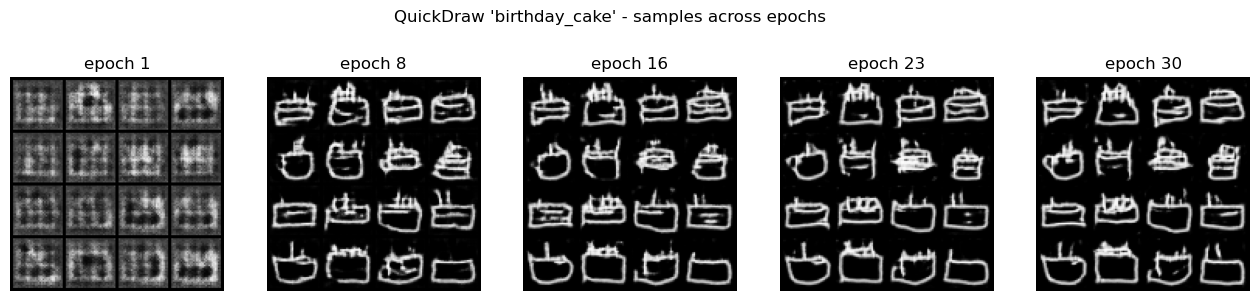

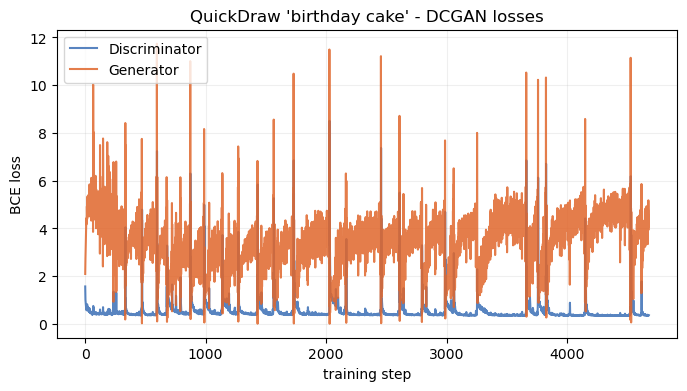

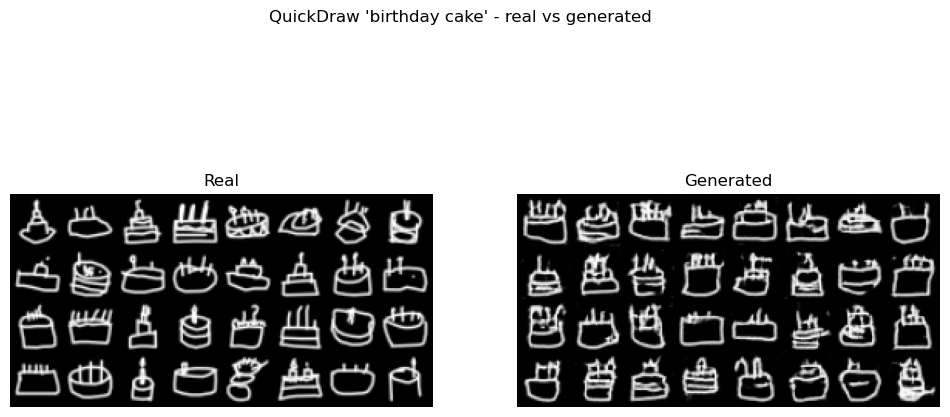

QuickDraw birthday cake: FID = 34.29


In [41]:
QUICKDRAW_EPOCHS = 30
cake_loader = build_quickdraw_loader(cake_images)
cake_generator, cake_g_losses, cake_d_losses = train_quickdraw_dcgan(cake_loader, QUICKDRAW_EPOCHS, "birthday_cake")
plot_gan_losses(cake_d_losses, cake_g_losses, "QuickDraw 'birthday cake' - DCGAN losses", "qd_cake_losses.png")

cake_fake = quickdraw_generate(cake_generator, 2000)
show_real_vs_fake(to_pm1_tensor(cake_images[:32]), cake_fake[:32],
                  "QuickDraw 'birthday cake' - real vs generated", "qd_cake_real_vs_fake.png")
cake_fid = score_fid(cake_images, cake_fake, "QuickDraw birthday cake")

## d) Extension - Other categories and sketch complexity

For the extension I run the exact same DCGAN on a few more QuickDraw categories and compare their FID scores against an ink-density proxy for complexity, which is basically how much of the canvas is drawn on. My expectation going in was that busier, denser sketches would be harder to model, so higher ink density should roughly go with higher FID.

downloading QuickDraw category: cat
[cat] epoch   1/30 | D=0.542 | G=5.038
[cat] epoch   2/30 | D=0.532 | G=2.827
[cat] epoch   3/30 | D=0.492 | G=3.363
[cat] epoch   4/30 | D=0.415 | G=3.078
[cat] epoch   5/30 | D=0.450 | G=3.242
[cat] epoch   6/30 | D=0.484 | G=2.426
[cat] epoch   7/30 | D=0.467 | G=2.837
[cat] epoch   8/30 | D=0.693 | G=2.291
[cat] epoch   9/30 | D=0.988 | G=1.013
[cat] epoch  10/30 | D=0.443 | G=2.779
[cat] epoch  11/30 | D=0.410 | G=2.926
[cat] epoch  12/30 | D=0.451 | G=2.357
[cat] epoch  13/30 | D=0.414 | G=2.886
[cat] epoch  14/30 | D=0.482 | G=2.883
[cat] epoch  15/30 | D=0.507 | G=2.445
[cat] epoch  16/30 | D=0.933 | G=2.477
[cat] epoch  17/30 | D=0.371 | G=4.097
[cat] epoch  18/30 | D=0.381 | G=3.680
[cat] epoch  19/30 | D=0.686 | G=3.990
[cat] epoch  20/30 | D=0.506 | G=2.505
[cat] epoch  21/30 | D=0.639 | G=1.697
[cat] epoch  22/30 | D=0.357 | G=4.947
[cat] epoch  23/30 | D=0.361 | G=4.408
[cat] epoch  24/30 | D=0.368 | G=3.920
[cat] epoch  25/30 | D=0.348

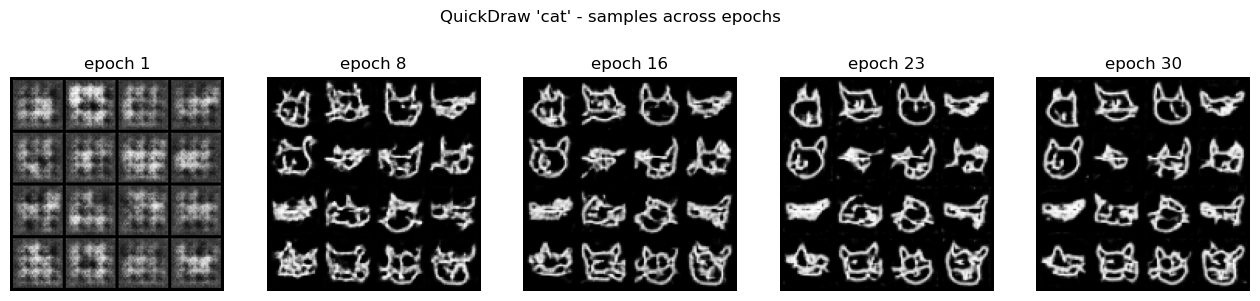

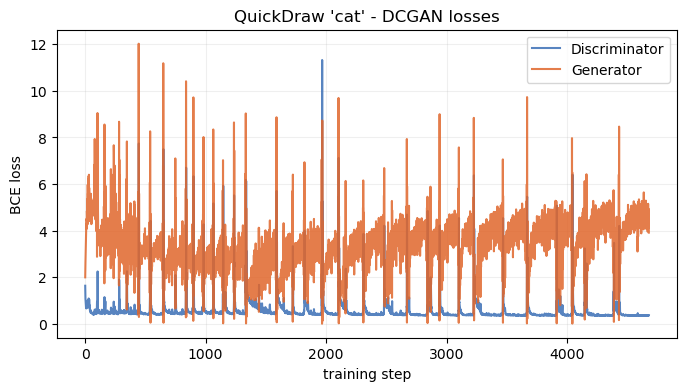

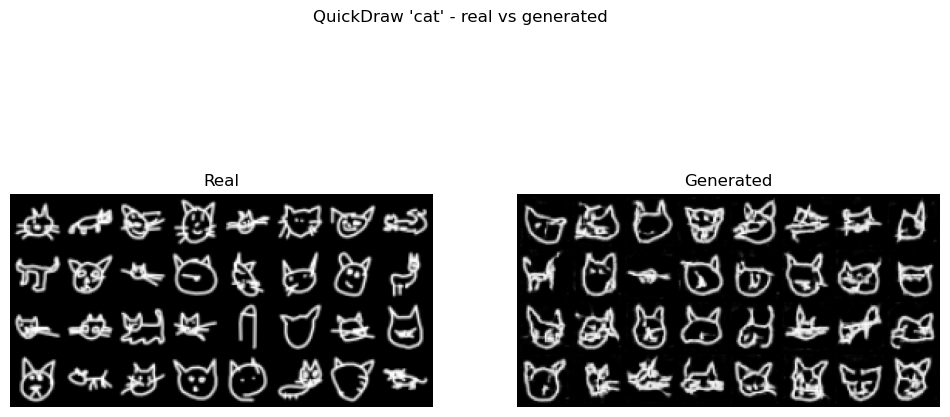

QuickDraw cat: FID = 38.79
downloading QuickDraw category: house
[house] epoch   1/30 | D=0.422 | G=3.734
[house] epoch   2/30 | D=0.434 | G=3.347
[house] epoch   3/30 | D=0.615 | G=2.338
[house] epoch   4/30 | D=1.123 | G=3.494
[house] epoch   5/30 | D=0.444 | G=3.291
[house] epoch   6/30 | D=0.518 | G=2.984
[house] epoch   7/30 | D=0.407 | G=3.120
[house] epoch   8/30 | D=0.772 | G=2.842
[house] epoch   9/30 | D=0.431 | G=3.272
[house] epoch  10/30 | D=0.383 | G=3.479
[house] epoch  11/30 | D=0.388 | G=3.571
[house] epoch  12/30 | D=0.464 | G=3.022
[house] epoch  13/30 | D=0.411 | G=3.692
[house] epoch  14/30 | D=0.393 | G=3.588
[house] epoch  15/30 | D=0.995 | G=5.389
[house] epoch  16/30 | D=0.381 | G=3.058
[house] epoch  17/30 | D=0.414 | G=3.056
[house] epoch  18/30 | D=0.402 | G=4.134
[house] epoch  19/30 | D=0.403 | G=3.729
[house] epoch  20/30 | D=0.432 | G=3.128
[house] epoch  21/30 | D=0.370 | G=4.163
[house] epoch  22/30 | D=0.367 | G=3.763
[house] epoch  23/30 | D=0.469 | 

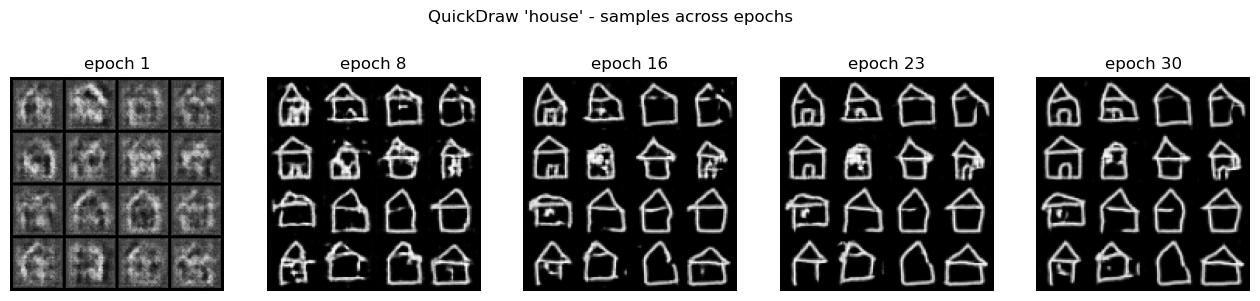

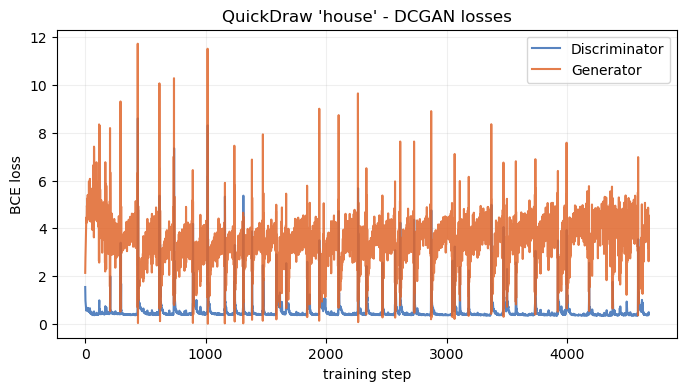

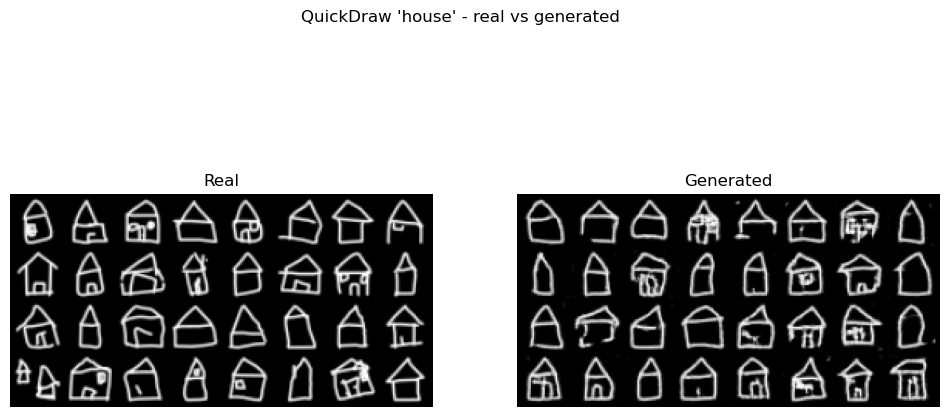

QuickDraw house: FID = 26.44


In [42]:
quickdraw_fid_by_category = {"birthday cake": cake_fid}
quickdraw_ink_by_category = {"birthday cake": ink_density(cake_images)}

for category in QUICKDRAW_EXTRA_CATEGORIES:
    category_images = download_quickdraw(category)
    quickdraw_ink_by_category[category] = ink_density(category_images)
    category_loader = build_quickdraw_loader(category_images)
    category_generator, category_g, category_d = train_quickdraw_dcgan(category_loader, QUICKDRAW_EPOCHS, category)
    plot_gan_losses(category_d, category_g, f"QuickDraw '{category}' - DCGAN losses", f"qd_{category}_losses.png")
    category_fake = quickdraw_generate(category_generator, 2000)
    show_real_vs_fake(to_pm1_tensor(category_images[:32]), category_fake[:32],
                      f"QuickDraw '{category}' - real vs generated", f"qd_{category}_real_vs_fake.png")
    quickdraw_fid_by_category[category] = score_fid(category_images, category_fake, f"QuickDraw {category}")

In [ ]:
category_names = list(quickdraw_fid_by_category.keys())
summary_panels = [
    ("FID by category (lower is better)", quickdraw_fid_by_category, "#3b6fb5"),
    ("Ink-density complexity proxy", quickdraw_ink_by_category, "#e0662b"),
]
figure, axes = plt.subplots(1, len(summary_panels), figsize=(12, 4))
for axis, (panel_title, metric_map, colour) in zip(axes, summary_panels):
    axis.bar(category_names, [metric_map[name] for name in category_names], color=colour)
    axis.set_title(panel_title)
    axis.tick_params(axis="x", rotation=20)
figure.suptitle("QuickDraw extension: FID vs ink-density complexity")
figure.savefig(os.path.join(RESULTS_DIR, "qd_extension_summary.png"), dpi=150, bbox_inches="tight")
plt.show()
print("QuickDraw category summary:")
for name in category_names:
    print(f"  {name:>14}: FID={quickdraw_fid_by_category[name]:.2f} | ink-density={quickdraw_ink_by_category[name]:.4f}")


## e) Reflection

The generated cakes are easy to read as cakes. Most have a rounded or boxy body with a few candle-like strokes on top, and a fair number even add a plate or a base line underneath. They are not all tidy - some have broken or doubled lines and a little background speckle - but the basic silhouette is consistent right across the grid, and I see no sign of mode collapse where the generator falls back on one repeated drawing. The loss traces support that reading: nothing diverged over the 30 epochs, which matches the samples looking coherent by the end rather than falling apart.

The more interesting result is how FID relates to sketch complexity. Ordering the categories by ink density gives house (0.1725), then cat (0.1986), then cake (0.1989), while ordering by FID gives house (26.44), then cake (34.29), then cat (38.79). House is the sparsest category and also the easiest to model, which fits the idea that emptier sketches are simpler to learn. But cat and cake sit at almost the same ink density, and cat still scores clearly worse, so ink density on its own does not explain the ranking. My reading is that cat sketches vary far more in pose and internal detail - ears, whiskers, the angle of the body - than cakes do, and it is that structural variety, rather than the sheer amount of ink, that makes the cat category the harder one to model.